<a href="https://colab.research.google.com/github/srushtidayanand/XAIforFL_medical_Diagnostics/blob/main/FL_dense121_dns.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# -------------------------------
# STEP 0: INSTALL AND IMPORT LIBRARIES
# -------------------------------

!pip install kagglehub --quiet

In [ ]:
import os
import glob
import zipfile
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
import kagglehub

In [ ]:
import kagglehub
import os

# Download latest version (it will be a folder)
path = kagglehub.dataset_download("bmadushanirodrigo/fracture-multi-region-x-ray-data")
print("Dataset path (already extracted):", path)

# Set data directory directly
data_dir = path  # this points to the extracted folder

Using Colab cache for faster access to the 'fracture-multi-region-x-ray-data' dataset.
Dataset path (already extracted): /kaggle/input/fracture-multi-region-x-ray-data


In [ ]:
data_dir = "/kaggle/input/fracture-multi-region-x-ray-data/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification"

In [ ]:
data_dir = "/root/.cache/kagglehub/datasets/bmadushanirodrigo/fracture-multi-region-x-ray-data/versions/2"

In [ ]:
# --------------------------------------
# ✅ Set dataset path manually
# --------------------------------------

# Directly assign your dataset path
data_dir = "/kaggle/input/fracture-multi-region-x-ray-data/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification"

print("Dataset path set to:", data_dir)


Dataset path set to: /kaggle/input/fracture-multi-region-x-ray-data/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification


In [ ]:
import kagglehub
import os

# ❌ Comment out dataset download (you already have it)
# path = kagglehub.dataset_download("bmadushanirodrigo/fracture-multi-region-x-ray-data")
# print("Dataset path (already extracted):", path)

# ✅ Set your dataset path manually
data_dir = "/kaggle/input/fracture-multi-region-x-ray-data/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification"

print("Dataset path set to:", data_dir)


Dataset path set to: /kaggle/input/fracture-multi-region-x-ray-data/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification


In [ ]:
# -------------------------------
# STEP 0: IMPORT LIBRARIES
# -------------------------------
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

# -------------------------------
# STEP 1: PARAMETERS
# -------------------------------
IMG_HEIGHT, IMG_WIDTH = 224, 224
BATCH_SIZE = 16
EPOCHS_BASELINE = 2
EPOCHS_CLIENT = 2
NUM_CLIENTS = 3
FED_ROUNDS = 3
LR = 1e-4

data_dir = "/kaggle/input/fracture-multi-region-x-ray-data/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification"
MODEL_DIR = "/content/drive/MyDrive/federated_model"
os.makedirs(MODEL_DIR, exist_ok=True)

# -------------------------------
# STEP 2: DATA PREPROCESSING
# -------------------------------
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)
val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    os.path.join(data_dir, "train"),
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=True
)
val_generator = val_test_datagen.flow_from_directory(
    os.path.join(data_dir, "val"),
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)
test_generator = val_test_datagen.flow_from_directory(
    os.path.join(data_dir, "test"),
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

# -------------------------------
# STEP 3: MODEL
# -------------------------------
def build_model():
    base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(IMG_HEIGHT, IMG_WIDTH, 3))
    x = GlobalAveragePooling2D()(base_model.output)
    x = Dense(128, activation='relu')(x)
    predictions = Dense(1, activation='sigmoid')(x)
    model = Model(inputs=base_model.input, outputs=predictions)

    for layer in base_model.layers:
        layer.trainable = False

    model.compile(optimizer=Adam(learning_rate=LR), loss='binary_crossentropy', metrics=['accuracy'])
    return model

# -------------------------------
# STEP 4: BASELINE MODEL
# -------------------------------
baseline_path = os.path.join(MODEL_DIR, "baseline_model.h5")
if os.path.exists(baseline_path):
    print("✅ Loading existing baseline model...")
    baseline_model = load_model(baseline_path)
else:
    print("\n🚀 Training baseline DenseNet121...")
    baseline_model = build_model()
    checkpoint = ModelCheckpoint(baseline_path, monitor='val_accuracy', save_best_only=True)
    baseline_model.fit(
        train_generator,
        validation_data=val_generator,
        epochs=EPOCHS_BASELINE,
        callbacks=[checkpoint]
    )
    print("Baseline model saved at:", baseline_path)

loss, acc = baseline_model.evaluate(val_generator)
print(f"\n✅ Baseline Accuracy: {acc*100:.2f}%")

# -------------------------------
# STEP 5: SIMULATED FEDERATED LEARNING (Weighted by Sample Count)
# -------------------------------

total_samples = train_generator.samples
indices = np.arange(total_samples)
np.random.shuffle(indices)

# Unequal data splits for hospitals (non-IID)
split_ratios = np.random.dirichlet(np.ones(NUM_CLIENTS), size=1)[0]  # e.g. [0.6, 0.3, 0.1]
split_sizes = (split_ratios * total_samples).astype(int)

# Make sure splits sum correctly
split_sizes[-1] = total_samples - np.sum(split_sizes[:-1])

client_indices = []
start = 0
for s in split_sizes:
    end = start + s
    client_indices.append(indices[start:end])
    start = end

print("\n📊 Client sample distribution:")
for i, s in enumerate(split_sizes):
    print(f"Client {i+1}: {s} samples ({100*s/total_samples:.2f}%)")

def get_client_generator(generator, indices):
    while True:
        generator.reset()
        for x_batch, y_batch in generator:
            start_idx = (generator.batch_index - 1) * generator.batch_size
            mask = [
                i for i in range(len(y_batch))
                if start_idx + i in indices
            ]
            if mask:
                yield x_batch[mask], y_batch[mask]

def weighted_fedavg(models, sample_counts):
    total = np.sum(sample_counts)
    avg_weights = []
    for weights_tuple in zip(*[m.get_weights() for m in models]):
        weighted_sum = np.zeros_like(weights_tuple[0])
        for w, n in zip(weights_tuple, sample_counts):
            weighted_sum += w * (n / total)
        avg_weights.append(weighted_sum)
    return avg_weights

# -------------------------------
# STEP 6: TRAIN FEDERATED ROUNDS
# -------------------------------
global_model_path = os.path.join(MODEL_DIR, "global_model.h5")
global_model = build_model()
global_model.set_weights(baseline_model.get_weights())

for rnd in range(FED_ROUNDS):
    print(f"\n🌍 Federated Round {rnd+1}/{FED_ROUNDS}")
    local_models = []
    sample_counts = []

    for i, client_idx in enumerate(client_indices):
        print(f"\n🏥 Training Client {i+1} ({len(client_idx)} samples)")
        client_gen = get_client_generator(train_generator, client_idx)
        steps = int(np.ceil(len(client_idx) / BATCH_SIZE))

        local_model = build_model()
        local_model.set_weights(global_model.get_weights())
        local_model.fit(client_gen, epochs=EPOCHS_CLIENT, steps_per_epoch=steps, verbose=1)

        local_models.append(local_model)
        sample_counts.append(len(client_idx))

    new_weights = weighted_fedavg(local_models, sample_counts)
    global_model.set_weights(new_weights)
    global_model.save(global_model_path)
    print(f"✅ Saved global model after round {rnd+1} to {global_model_path}")

# -------------------------------
# STEP 7: FINAL EVALUATION
# -------------------------------
loss, acc = global_model.evaluate(test_generator)
print(f"\n🏁 Final Global Accuracy after Federated Learning: {acc*100:.2f}%")


Found 9246 images belonging to 2 classes.
Found 829 images belonging to 2 classes.
Found 506 images belonging to 2 classes.

🚀 Training baseline DenseNet121...
Epoch 1/2
578/578 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7020 - loss: 0.5602

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


578/578 ━━━━━━━━━━━━━━━━━━━━ 1476s 3s/step - accuracy: 0.7022 - loss: 0.5600 - val_accuracy: 0.8408 - val_loss: 0.3727
Epoch 2/2
578/578 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8646 - loss: 0.3554

578/578 ━━━━━━━━━━━━━━━━━━━━ 1486s 3s/step - accuracy: 0.8646 - loss: 0.3553 - val_accuracy: 0.8649 - val_loss: 0.3234
Baseline model saved at: /content/drive/MyDrive/federated_model/baseline_model.h5
52/52 ━━━━━━━━━━━━━━━━━━━━ 116s 2s/step - accuracy: 0.9197 - loss: 0.2550

✅ Baseline Accuracy: 86.49%

📊 Client sample distribution:
Client 1: 8246 samples (89.18%)
Client 2: 73 samples (0.79%)
Client 3: 927 samples (10.03%)

🌍 Federated Round 1/3

🏥 Training Client 1 (8246 samples)
516/516 ━━━━━━━━━━━━━━━━━━━━ 1108s 2s/step - accuracy: 0.8885 - loss: 0.2917

🏥 Training Client 2 (73 samples)
5/5 ━━━━━━━━━━━━━━━━━━━━ 17s 542ms/step - accuracy: 1.0000 - loss: 0.2189

🏥 Training Client 3 (927 samples)
58/58 ━━━━━━━━━━━━━━━━━━━━ 43s 505ms/step - accuracy: 0.9553 - loss: 0.2513


✅ Saved global model after round 1 to /content/drive/MyDrive/federated_model/global_model.h5

🌍 Federated Round 2/3

🏥 Training Client 1 (8246 samples)
516/516 ━━━━━━━━━━━━━━━━━━━━ 1102s 2s/step - accuracy: 0.9102 - loss: 0.2509

🏥 Training Client 2 (73 samples)
5/5 ━━━━━━━━━━━━━━━━━━━━ 18s 579ms/step - accuracy: 0.8361 - loss: 0.2100

🏥 Training Client 3 (927 samples)
58/58 ━━━━━━━━━━━━━━━━━━━━ 43s 497ms/step - accuracy: 0.8932 - loss: 0.3188


✅ Saved global model after round 2 to /content/drive/MyDrive/federated_model/global_model.h5

🌍 Federated Round 3/3

🏥 Training Client 1 (8246 samples)
516/516 ━━━━━━━━━━━━━━━━━━━━ 1105s 2s/step - accuracy: 0.9227 - loss: 0.2197

🏥 Training Client 2 (73 samples)
5/5 ━━━━━━━━━━━━━━━━━━━━ 17s 680ms/step - accuracy: 1.0000 - loss: 0.1302

🏥 Training Client 3 (927 samples)
58/58 ━━━━━━━━━━━━━━━━━━━━ 44s 520ms/step - accuracy: 0.9645 - loss: 0.1982


✅ Saved global model after round 3 to /content/drive/MyDrive/federated_model/global_model.h5
32/32 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - accuracy: 0.8806 - loss: 0.2816

🏁 Final Global Accuracy after Federated Learning: 88.74%


In [ ]:
# -------------------------------
# STEP 0: IMPORT LIBRARIES
# -------------------------------
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

# -------------------------------
# STEP 1: PARAMETERS
# -------------------------------
IMG_HEIGHT, IMG_WIDTH = 224, 224
BATCH_SIZE = 16
EPOCHS_BASELINE = 2
EPOCHS_CLIENT = 2
NUM_CLIENTS = 3
FED_ROUNDS = 3
LR = 1e-4

data_dir = "/kaggle/input/fracture-multi-region-x-ray-data/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification"
MODEL_DIR = "/content/drive/MyDrive/federated_model"
os.makedirs(MODEL_DIR, exist_ok=True)

# -------------------------------
# STEP 2: DATA PREPROCESSING
# -------------------------------
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)
val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    os.path.join(data_dir, "train"),
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=True
)
val_generator = val_test_datagen.flow_from_directory(
    os.path.join(data_dir, "val"),
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)
test_generator = val_test_datagen.flow_from_directory(
    os.path.join(data_dir, "test"),
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

# -------------------------------
# STEP 3: MODEL
# -------------------------------
def build_model():
    base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(IMG_HEIGHT, IMG_WIDTH, 3))
    x = GlobalAveragePooling2D()(base_model.output)
    x = Dense(128, activation='relu')(x)
    predictions = Dense(1, activation='sigmoid')(x)
    model = Model(inputs=base_model.input, outputs=predictions)

    for layer in base_model.layers:
        layer.trainable = False

    model.compile(optimizer=Adam(learning_rate=LR), loss='binary_crossentropy', metrics=['accuracy'])
    return model

# # -------------------------------
# # STEP 4: BASELINE MODEL
# # -------------------------------
# baseline_path = os.path.join(MODEL_DIR, "baseline_model.h5")
# if os.path.exists(baseline_path):
#     print("✅ Loading existing baseline model...")
#     baseline_model = load_model(baseline_path)
# else:
#     print("\n🚀 Training baseline DenseNet121...")
#     baseline_model = build_model()
#     checkpoint = ModelCheckpoint(baseline_path, monitor='val_accuracy', save_best_only=True)
#     baseline_model.fit(
#         train_generator,
#         validation_data=val_generator,
#         epochs=EPOCHS_BASELINE,
#         callbacks=[checkpoint]
#     )
#     print("Baseline model saved at:", baseline_path)

# loss, acc = baseline_model.evaluate(val_generator)
# print(f"\n✅ Baseline Accuracy: {acc*100:.2f}%")

# -------------------------------
# STEP 5: SIMULATED FEDERATED LEARNING (Weighted by Sample Count)
# -------------------------------

total_samples = train_generator.samples
indices = np.arange(total_samples)
np.random.shuffle(indices)

# Unequal data splits for hospitals (non-IID)
split_ratios = np.random.dirichlet(np.ones(NUM_CLIENTS), size=1)[0]  # e.g. [0.6, 0.3, 0.1]
split_sizes = (split_ratios * total_samples).astype(int)

# Make sure splits sum correctly
split_sizes[-1] = total_samples - np.sum(split_sizes[:-1])

client_indices = []
start = 0
for s in split_sizes:
    end = start + s
    client_indices.append(indices[start:end])
    start = end

print("\n📊 Client sample distribution:")
for i, s in enumerate(split_sizes):
    print(f"Client {i+1}: {s} samples ({100*s/total_samples:.2f}%)")

def get_client_generator(generator, indices):
    while True:
        generator.reset()
        for x_batch, y_batch in generator:
            start_idx = (generator.batch_index - 1) * generator.batch_size
            mask = [
                i for i in range(len(y_batch))
                if start_idx + i in indices
            ]
            if mask:
                yield x_batch[mask], y_batch[mask]

def weighted_fedavg(models, sample_counts):
    total = np.sum(sample_counts)
    avg_weights = []
    for weights_tuple in zip(*[m.get_weights() for m in models]):
        weighted_sum = np.zeros_like(weights_tuple[0])
        for w, n in zip(weights_tuple, sample_counts):
            weighted_sum += w * (n / total)
        avg_weights.append(weighted_sum)
    return avg_weights

# -------------------------------
# STEP 6: TRAIN FEDERATED ROUNDS
# -------------------------------
global_model_path = os.path.join(MODEL_DIR, "global_model.h5")
global_model = build_model()
global_model.set_weights(baseline_model.get_weights())

for rnd in range(FED_ROUNDS):
    print(f"\n🌍 Federated Round {rnd+1}/{FED_ROUNDS}")
    local_models = []
    sample_counts = []

    for i, client_idx in enumerate(client_indices):
        print(f"\n🏥 Training Client {i+1} ({len(client_idx)} samples)")
        client_gen = get_client_generator(train_generator, client_idx)
        steps = int(np.ceil(len(client_idx) / BATCH_SIZE))

        local_model = build_model()
        local_model.set_weights(global_model.get_weights())
        local_model.fit(client_gen, epochs=EPOCHS_CLIENT, steps_per_epoch=steps, verbose=1)

        local_models.append(local_model)
        sample_counts.append(len(client_idx))

    new_weights = weighted_fedavg(local_models, sample_counts)
    global_model.set_weights(new_weights)
    global_model.save(global_model_path)
    print(f"✅ Saved global model after round {rnd+1} to {global_model_path}")

# -------------------------------
# STEP 7: FINAL EVALUATION
# -------------------------------
loss, acc = global_model.evaluate(test_generator)
print(f"\n🏁 Final Global Accuracy after Federated Learning: {acc*100:.2f}%")


Found 9246 images belonging to 2 classes.
Found 829 images belonging to 2 classes.
Found 506 images belonging to 2 classes.

📊 Client sample distribution:
Client 1: 3326 samples (35.97%)
Client 2: 2931 samples (31.70%)
Client 3: 2989 samples (32.33%)

🌍 Federated Round 1/3

🏥 Training Client 1 (3326 samples)
Epoch 1/2
208/208 ━━━━━━━━━━━━━━━━━━━━ 133s 596ms/step - accuracy: 0.6114 - loss: 0.6394
Epoch 2/2
208/208 ━━━━━━━━━━━━━━━━━━━━ 128s 614ms/step - accuracy: 0.7327 - loss: 0.5511

🏥 Training Client 2 (2931 samples)
Epoch 1/2
184/184 ━━━━━━━━━━━━━━━━━━━━ 110s 548ms/step - accuracy: 0.5562 - loss: 0.6837
Epoch 2/2
184/184 ━━━━━━━━━━━━━━━━━━━━ 99s 540ms/step - accuracy: 0.7365 - loss: 0.5342

🏥 Training Client 3 (2989 samples)
Epoch 1/2
187/187 ━━━━━━━━━━━━━━━━━━━━ 114s 560ms/step - accuracy: 0.5550 - loss: 0.6961
Epoch 2/2
187/187 ━━━━━━━━━━━━━━━━━━━━ 99s 530ms/step - accuracy: 0.7295 - loss: 0.5531


✅ Saved global model after round 1 to /content/drive/MyDrive/federated_model/global_model.h5

🌍 Federated Round 2/3

🏥 Training Client 1 (3326 samples)
Epoch 1/2
208/208 ━━━━━━━━━━━━━━━━━━━━ 131s 587ms/step - accuracy: 0.7731 - loss: 0.5042
Epoch 2/2
208/208 ━━━━━━━━━━━━━━━━━━━━ 126s 605ms/step - accuracy: 0.7842 - loss: 0.4740

🏥 Training Client 2 (2931 samples)
Epoch 1/2
184/184 ━━━━━━━━━━━━━━━━━━━━ 116s 560ms/step - accuracy: 0.7597 - loss: 0.4855
Epoch 2/2
184/184 ━━━━━━━━━━━━━━━━━━━━ 101s 549ms/step - accuracy: 0.7987 - loss: 0.4497

🏥 Training Client 3 (2989 samples)
Epoch 1/2
187/187 ━━━━━━━━━━━━━━━━━━━━ 117s 572ms/step - accuracy: 0.7796 - loss: 0.4853
Epoch 2/2
187/187 ━━━━━━━━━━━━━━━━━━━━ 102s 544ms/step - accuracy: 0.8145 - loss: 0.4364


✅ Saved global model after round 2 to /content/drive/MyDrive/federated_model/global_model.h5

🌍 Federated Round 3/3

🏥 Training Client 1 (3326 samples)
Epoch 1/2
208/208 ━━━━━━━━━━━━━━━━━━━━ 132s 590ms/step - accuracy: 0.8286 - loss: 0.4299
Epoch 2/2
208/208 ━━━━━━━━━━━━━━━━━━━━ 127s 610ms/step - accuracy: 0.8389 - loss: 0.3993

🏥 Training Client 2 (2931 samples)
Epoch 1/2
184/184 ━━━━━━━━━━━━━━━━━━━━ 110s 548ms/step - accuracy: 0.8404 - loss: 0.4151
Epoch 2/2
184/184 ━━━━━━━━━━━━━━━━━━━━ 98s 536ms/step - accuracy: 0.8135 - loss: 0.4162

🏥 Training Client 3 (2989 samples)
Epoch 1/2
187/187 ━━━━━━━━━━━━━━━━━━━━ 116s 563ms/step - accuracy: 0.8006 - loss: 0.4412
Epoch 2/2
187/187 ━━━━━━━━━━━━━━━━━━━━ 101s 538ms/step - accuracy: 0.7897 - loss: 0.4367


✅ Saved global model after round 3 to /content/drive/MyDrive/federated_model/global_model.h5
32/32 ━━━━━━━━━━━━━━━━━━━━ 55s 2s/step - accuracy: 0.7076 - loss: 0.5069

🏁 Final Global Accuracy after Federated Learning: 76.88%


In [ ]:
# STEP 7: FINAL EVALUATION
# -------------------------------
loss, acc = global_model.evaluate(test_generator)
print(f"\n🏁 Final Global Accuracy after Federated Learning: {acc*100:.2f}%")


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


32/32 ━━━━━━━━━━━━━━━━━━━━ 88s 2s/step - accuracy: 0.8808 - loss: 0.2831

🏁 Final Global Accuracy after Federated Learning: 88.14%


Improved model 2.0


In [ ]:
# -------------------------------
# STEP 3: IMPROVED MODEL (Fine-tuned DenseNet121 + Custom Layers)
# -------------------------------
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Model
from tensorflow.keras.applications import DenseNet121

def build_improved_model():
    base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(IMG_HEIGHT, IMG_WIDTH, 3))

    # 🔹 Unfreeze top 30 layers for fine-tuning (makes model learn dataset-specific patterns)
    for layer in base_model.layers[:-30]:
        layer.trainable = False
    for layer in base_model.layers[-30:]:
        layer.trainable = True

    # 🔹 Add improved classification head
    x = GlobalAveragePooling2D()(base_model.output)
    x = BatchNormalization()(x)
    x = Dense(512, activation='relu')(x)     # Larger capacity
    x = Dropout(0.5)(x)                      # Strong regularization
    x = Dense(256, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    output = Dense(1, activation='sigmoid')(x)

    model = Model(inputs=base_model.input, outputs=output)

    # 🔹 Use lower learning rate to avoid destroying pretrained weights
    model.compile(optimizer=Adam(learning_rate=1e-5),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model


In [ ]:
# -------------------------------
# STEP 5: SIMULATED FEDERATED LEARNING (Weighted by Sample Count)
# -------------------------------

total_samples = train_generator.samples
indices = np.arange(total_samples)
np.random.shuffle(indices)

# Unequal data splits for hospitals (non-IID)
split_ratios = np.random.dirichlet(np.ones(NUM_CLIENTS), size=1)[0]  # e.g. [0.6, 0.3, 0.1]
split_sizes = (split_ratios * total_samples).astype(int)

# Make sure splits sum correctly
split_sizes[-1] = total_samples - np.sum(split_sizes[:-1])

client_indices = []
start = 0
for s in split_sizes:
    end = start + s
    client_indices.append(indices[start:end])
    start = end

print("\n📊 Client sample distribution:")
for i, s in enumerate(split_sizes):
    print(f"Client {i+1}: {s} samples ({100*s/total_samples:.2f}%)")

def get_client_generator(generator, indices):
    while True:
        generator.reset()
        for x_batch, y_batch in generator:
            start_idx = (generator.batch_index - 1) * generator.batch_size
            mask = [
                i for i in range(len(y_batch))
                if start_idx + i in indices
            ]
            if mask:
                yield x_batch[mask], y_batch[mask]

def weighted_fedavg(models, sample_counts):
    total = np.sum(sample_counts)
    avg_weights = []
    for weights_tuple in zip(*[m.get_weights() for m in models]):
        weighted_sum = np.zeros_like(weights_tuple[0])
        for w, n in zip(weights_tuple, sample_counts):
            weighted_sum += w * (n / total)
        avg_weights.append(weighted_sum)
    return avg_weights

# -------------------------------
# STEP 6: TRAIN FEDERATED ROUNDS
# -------------------------------
global_model_path = os.path.join(MODEL_DIR, "global_model.h5")
global_model = build_model()
global_model.set_weights(baseline_model.get_weights())

for rnd in range(FED_ROUNDS):
    print(f"\n🌍 Federated Round {rnd+1}/{FED_ROUNDS}")
    local_models = []
    sample_counts = []

    for i, client_idx in enumerate(client_indices):
        print(f"\n🏥 Training Client {i+1} ({len(client_idx)} samples)")
        client_gen = get_client_generator(train_generator, client_idx)
        steps = int(np.ceil(len(client_idx) / BATCH_SIZE))

        local_model = build_model()
        local_model.set_weights(global_model.get_weights())
        local_model.fit(client_gen, epochs=EPOCHS_CLIENT, steps_per_epoch=steps, verbose=1)

        local_models.append(local_model)
        sample_counts.append(len(client_idx))

    new_weights = weighted_fedavg(local_models, sample_counts)
    global_model.set_weights(new_weights)
    global_model.save(global_model_path)
    print(f"✅ Saved global model after round {rnd+1} to {global_model_path}")

# -------------------------------
# STEP 7: FINAL EVALUATION
# -------------------------------
loss, acc = global_model.evaluate(test_generator)
print(f"\n🏁 Final Global Accuracy after Federated Learning: {acc*100:.2f}%")


📊 Client sample distribution:
Client 1: 1608 samples (17.39%)
Client 2: 4072 samples (44.04%)
Client 3: 3566 samples (38.57%)

🌍 Federated Round 1/3

🏥 Training Client 1 (1608 samples)
Epoch 1/2
101/101 ━━━━━━━━━━━━━━━━━━━━ 49s 394ms/step - accuracy: 0.5909 - loss: 0.6787
Epoch 2/2
101/101 ━━━━━━━━━━━━━━━━━━━━ 36s 354ms/step - accuracy: 0.4835 - loss: 0.7663

🏥 Training Client 2 (4072 samples)
Epoch 1/2
255/255 ━━━━━━━━━━━━━━━━━━━━ 193s 712ms/step - accuracy: 0.4736 - loss: 0.7474
Epoch 2/2
255/255 ━━━━━━━━━━━━━━━━━━━━ 190s 746ms/step - accuracy: 0.5839 - loss: 0.6716

🏥 Training Client 3 (3566 samples)
Epoch 1/2
223/223 ━━━━━━━━━━━━━━━━━━━━ 154s 650ms/step - accuracy: 0.5126 - loss: 0.7124
Epoch 2/2
223/223 ━━━━━━━━━━━━━━━━━━━━ 144s 644ms/step - accuracy: 0.5225 - loss: 0.7130


✅ Saved global model after round 1 to /content/drive/MyDrive/federated_model/global_model.h5

🌍 Federated Round 2/3

🏥 Training Client 1 (1608 samples)
Epoch 1/2
101/101 ━━━━━━━━━━━━━━━━━━━━ 48s 383ms/step - accuracy: 0.5925 - loss: 0.6675
Epoch 2/2
101/101 ━━━━━━━━━━━━━━━━━━━━ 36s 354ms/step - accuracy: 0.5834 - loss: 0.6668

🏥 Training Client 2 (4072 samples)
Epoch 1/2
255/255 ━━━━━━━━━━━━━━━━━━━━ 191s 712ms/step - accuracy: 0.6197 - loss: 0.6596
Epoch 2/2
255/255 ━━━━━━━━━━━━━━━━━━━━ 190s 743ms/step - accuracy: 0.6478 - loss: 0.6290

🏥 Training Client 3 (3566 samples)
Epoch 1/2
223/223 ━━━━━━━━━━━━━━━━━━━━ 154s 650ms/step - accuracy: 0.6165 - loss: 0.6430
Epoch 2/2
223/223 ━━━━━━━━━━━━━━━━━━━━ 143s 639ms/step - accuracy: 0.6252 - loss: 0.6299


✅ Saved global model after round 2 to /content/drive/MyDrive/federated_model/global_model.h5

🌍 Federated Round 3/3

🏥 Training Client 1 (1608 samples)
Epoch 1/2
101/101 ━━━━━━━━━━━━━━━━━━━━ 48s 382ms/step - accuracy: 0.7018 - loss: 0.6098
Epoch 2/2
101/101 ━━━━━━━━━━━━━━━━━━━━ 35s 352ms/step - accuracy: 0.6498 - loss: 0.6192

🏥 Training Client 2 (4072 samples)
Epoch 1/2
255/255 ━━━━━━━━━━━━━━━━━━━━ 190s 707ms/step - accuracy: 0.6874 - loss: 0.6018
Epoch 2/2
255/255 ━━━━━━━━━━━━━━━━━━━━ 189s 741ms/step - accuracy: 0.7102 - loss: 0.5926

🏥 Training Client 3 (3566 samples)
Epoch 1/2
223/223 ━━━━━━━━━━━━━━━━━━━━ 154s 650ms/step - accuracy: 0.6616 - loss: 0.6235
Epoch 2/2
223/223 ━━━━━━━━━━━━━━━━━━━━ 142s 636ms/step - accuracy: 0.7060 - loss: 0.5859


✅ Saved global model after round 3 to /content/drive/MyDrive/federated_model/global_model.h5
32/32 ━━━━━━━━━━━━━━━━━━━━ 54s 2s/step - accuracy: 0.6367 - loss: 0.6212

🏁 Final Global Accuracy after Federated Learning: 61.86%


21/10/25


In [ ]:
# ====================================================
# ✅ FEDERATED LEARNING WITH RESUMABLE CHECKPOINTS
# ====================================================

# -------------------------------
# STEP 0: IMPORT LIBRARIES
# -------------------------------
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

In [ ]:
# -------------------------------
# STEP 1: PARAMETERS
# -------------------------------
IMG_HEIGHT, IMG_WIDTH = 224, 224
BATCH_SIZE = 16
EPOCHS_BASELINE = 2
EPOCHS_CLIENT = 2
NUM_CLIENTS = 3
FED_ROUNDS = 3
LR = 1e-4

data_dir = "/kaggle/input/fracture-multi-region-x-ray-data/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification"
MODEL_DIR = "/content/drive/MyDrive/federated_model"
os.makedirs(MODEL_DIR, exist_ok=True)

baseline_path = os.path.join(MODEL_DIR, "baseline_model.h5")
global_model_path = os.path.join(MODEL_DIR, "global_model_latest.h5")

In [ ]:
# -------------------------------
# STEP 2: DATA PREPROCESSING
# -------------------------------
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)
val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    os.path.join(data_dir, "train"),
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=True
)
val_generator = val_test_datagen.flow_from_directory(
    os.path.join(data_dir, "val"),
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)
test_generator = val_test_datagen.flow_from_directory(
    os.path.join(data_dir, "test"),
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)




Found 9246 images belonging to 2 classes.
Found 829 images belonging to 2 classes.
Found 506 images belonging to 2 classes.


In [ ]:
# -------------------------------
# STEP 3: IMPROVED MODEL (DenseNet121 + Custom Layers)
# -------------------------------
def build_model():
    base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(IMG_HEIGHT, IMG_WIDTH, 3))

    # Freeze base layers
    for layer in base_model.layers:
        layer.trainable = False

    # Add new classification head
    x = GlobalAveragePooling2D()(base_model.output)
    x = BatchNormalization()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.4)(x)
    x = Dense(128, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    output = Dense(1, activation='sigmoid')(x)

    model = Model(inputs=base_model.input, outputs=output)
    model.compile(optimizer=Adam(learning_rate=LR), loss='binary_crossentropy', metrics=['accuracy'])
    return model


In [ ]:
# -------------------------------
# STEP 3: IMPROVED MODEL (Optimized DenseNet121 + Deeper Head)
# VERSION: 3.0
# -------------------------------
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Model
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.activations import swish

In [ ]:
# -------------------------------
# STEP 4: BASELINE TRAINING OR LOAD
# -------------------------------
if os.path.exists(baseline_path):
    print("✅ Loading existing baseline model...")
    baseline_model = load_model(baseline_path)
else:
    print("\n🚀 Training baseline DenseNet121...")
    baseline_model = build_model()
    checkpoint = ModelCheckpoint(baseline_path, monitor='val_accuracy', save_best_only=True, verbose=1)
    baseline_model.fit(
        train_generator,
        validation_data=val_generator,
        epochs=EPOCHS_BASELINE,
        callbacks=[checkpoint]
    )
    print("✅ Baseline model saved at:", baseline_path)

loss, acc = baseline_model.evaluate(val_generator)
print(f"\n📊 Baseline Accuracy: {acc*100:.2f}%")


🚀 Training baseline DenseNet121...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/2
578/578 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step - accuracy: 0.6451 - loss: 0.6993

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(



Epoch 1: val_accuracy improved from -inf to 0.87455, saving model to /content/drive/MyDrive/federated_model/baseline_model.h5


578/578 ━━━━━━━━━━━━━━━━━━━━ 231s 346ms/step - accuracy: 0.6452 - loss: 0.6991 - val_accuracy: 0.8745 - val_loss: 0.2976
Epoch 2/2
578/578 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step - accuracy: 0.8285 - loss: 0.3878
Epoch 2: val_accuracy improved from 0.87455 to 0.92280, saving model to /content/drive/MyDrive/federated_model/baseline_model.h5


578/578 ━━━━━━━━━━━━━━━━━━━━ 140s 242ms/step - accuracy: 0.8285 - loss: 0.3877 - val_accuracy: 0.9228 - val_loss: 0.2153
✅ Baseline model saved at: /content/drive/MyDrive/federated_model/baseline_model.h5
52/52 ━━━━━━━━━━━━━━━━━━━━ 6s 111ms/step - accuracy: 0.9063 - loss: 0.2411

📊 Baseline Accuracy: 92.28%


In [ ]:


# -------------------------------
# STEP 5: CLIENT DATA SPLITTING (SIMULATION)
# -------------------------------
total_samples = train_generator.samples
indices = np.arange(total_samples)
np.random.shuffle(indices)

split_ratios = np.random.dirichlet(np.ones(NUM_CLIENTS), size=1)[0]
split_sizes = (split_ratios * total_samples).astype(int)
split_sizes[-1] = total_samples - np.sum(split_sizes[:-1])

client_indices = []
start = 0
for s in split_sizes:
    end = start + s
    client_indices.append(indices[start:end])
    start = end

print("\n📊 Client sample distribution:")
for i, s in enumerate(split_sizes):
    print(f"Client {i+1}: {s} samples ({100*s/total_samples:.2f}%)")


📊 Client sample distribution:
Client 1: 7911 samples (85.56%)
Client 2: 446 samples (4.82%)
Client 3: 889 samples (9.61%)


In [ ]:


# -------------------------------
# STEP 6: CLIENT GENERATOR
# -------------------------------
def get_client_generator(generator, indices):
    while True:
        generator.reset()
        for x_batch, y_batch in generator:
            start_idx = (generator.batch_index - 1) * generator.batch_size
            mask = [
                i for i in range(len(y_batch))
                if start_idx + i in indices
            ]
            if mask:
                yield x_batch[mask], y_batch[mask]

In [ ]:
# -------------------------------
# STEP 7: WEIGHTED FEDERATED AVERAGING
# -------------------------------
def weighted_fedavg(models, sample_counts):
    total = np.sum(sample_counts)
    avg_weights = []
    for weights_tuple in zip(*[m.get_weights() for m in models]):
        weighted_sum = np.zeros_like(weights_tuple[0])
        for w, n in zip(weights_tuple, sample_counts):
            weighted_sum += w * (n / total)
        avg_weights.append(weighted_sum)
    return avg_weights


In [ ]:
# -------------------------------
# STEP 8: RESUME GLOBAL MODEL IF EXISTS
# -------------------------------
if os.path.exists(global_model_path):
    print("✅ Loading existing global model...")
    global_model = load_model(global_model_path)
else:
    print("\n🚀 Initializing global model from baseline...")
    global_model = build_model()
    global_model.set_weights(baseline_model.get_weights())



🚀 Initializing global model from baseline...


In [ ]:

# -------------------------------
# STEP 9: FEDERATED TRAINING LOOP
# -------------------------------
start_round = 0
round_tracker_path = os.path.join(MODEL_DIR, "last_completed_round.txt")

if os.path.exists(round_tracker_path):
    with open(round_tracker_path, "r") as f:
        start_round = int(f.read().strip())
    print(f"🔁 Resuming from Federated Round {start_round + 1}")

for rnd in range(start_round, FED_ROUNDS):
    print(f"\n🌍 Federated Round {rnd + 1}/{FED_ROUNDS}")
    local_models = []
    sample_counts = []

    for i, client_idx in enumerate(client_indices):
        print(f"\n🏥 Training Client {i + 1} ({len(client_idx)} samples)")
        client_gen = get_client_generator(train_generator, client_idx)
        steps = int(np.ceil(len(client_idx) / BATCH_SIZE))

        local_model = build_model()
        local_model.set_weights(global_model.get_weights())
        local_model.fit(client_gen, epochs=EPOCHS_CLIENT, steps_per_epoch=steps, verbose=1)

        local_models.append(local_model)
        sample_counts.append(len(client_idx))

    new_weights = weighted_fedavg(local_models, sample_counts)
    global_model.set_weights(new_weights)
    global_model.save(global_model_path)

    # Save progress
    with open(round_tracker_path, "w") as f:
        f.write(str(rnd + 1))
    print(f"✅ Saved global model and progress after round {rnd + 1}")

# -------------------------------
# STEP 10: FINAL EVALUATION
# -------------------------------
loss, acc = global_model.evaluate(test_generator)
print(f"\n🏁 Final Global Accuracy after Federated Learning: {acc*100:.2f}%")



🌍 Federated Round 1/3

🏥 Training Client 1 (3295 samples)
Epoch 1/2
206/206 ━━━━━━━━━━━━━━━━━━━━ 209s 883ms/step - accuracy: 0.8044 - loss: 0.4197
Epoch 2/2
206/206 ━━━━━━━━━━━━━━━━━━━━ 44s 212ms/step - accuracy: 0.7999 - loss: 0.4167

🏥 Training Client 2 (2600 samples)
Epoch 1/2
163/163 ━━━━━━━━━━━━━━━━━━━━ 158s 815ms/step - accuracy: 0.7578 - loss: 0.5140
Epoch 2/2
163/163 ━━━━━━━━━━━━━━━━━━━━ 35s 212ms/step - accuracy: 0.8317 - loss: 0.3840

🏥 Training Client 3 (3351 samples)
Epoch 1/2
210/210 ━━━━━━━━━━━━━━━━━━━━ 191s 787ms/step - accuracy: 0.8348 - loss: 0.3693
Epoch 2/2
210/210 ━━━━━━━━━━━━━━━━━━━━ 46s 216ms/step - accuracy: 0.8418 - loss: 0.3786


✅ Saved global model and progress after round 1

🌍 Federated Round 2/3

🏥 Training Client 1 (3295 samples)
Epoch 1/2
206/206 ━━━━━━━━━━━━━━━━━━━━ 187s 787ms/step - accuracy: 0.8262 - loss: 0.3933
Epoch 2/2
206/206 ━━━━━━━━━━━━━━━━━━━━ 45s 218ms/step - accuracy: 0.8321 - loss: 0.3813

🏥 Training Client 2 (2600 samples)
Epoch 1/2
163/163 ━━━━━━━━━━━━━━━━━━━━ 161s 830ms/step - accuracy: 0.8261 - loss: 0.4269
Epoch 2/2
163/163 ━━━━━━━━━━━━━━━━━━━━ 36s 219ms/step - accuracy: 0.7723 - loss: 0.4551

🏥 Training Client 3 (3351 samples)
Epoch 1/2
210/210 ━━━━━━━━━━━━━━━━━━━━ 190s 781ms/step - accuracy: 0.8309 - loss: 0.3673
Epoch 2/2
210/210 ━━━━━━━━━━━━━━━━━━━━ 45s 215ms/step - accuracy: 0.8210 - loss: 0.4140


✅ Saved global model and progress after round 2

🌍 Federated Round 3/3

🏥 Training Client 1 (3295 samples)
Epoch 1/2
206/206 ━━━━━━━━━━━━━━━━━━━━ 188s 778ms/step - accuracy: 0.8330 - loss: 0.4043
Epoch 2/2
206/206 ━━━━━━━━━━━━━━━━━━━━ 45s 217ms/step - accuracy: 0.8478 - loss: 0.3734

🏥 Training Client 2 (2600 samples)
Epoch 1/2
163/163 ━━━━━━━━━━━━━━━━━━━━ 159s 826ms/step - accuracy: 0.8121 - loss: 0.3986
Epoch 2/2
163/163 ━━━━━━━━━━━━━━━━━━━━ 36s 218ms/step - accuracy: 0.8047 - loss: 0.4290

🏥 Training Client 3 (3351 samples)
Epoch 1/2
210/210 ━━━━━━━━━━━━━━━━━━━━ 199s 825ms/step - accuracy: 0.8648 - loss: 0.3331
Epoch 2/2
210/210 ━━━━━━━━━━━━━━━━━━━━ 51s 243ms/step - accuracy: 0.8452 - loss: 0.3551


✅ Saved global model and progress after round 3
32/32 ━━━━━━━━━━━━━━━━━━━━ 30s 453ms/step - accuracy: 0.8932 - loss: 0.2668

🏁 Final Global Accuracy after Federated Learning: 90.32%


continue

In [ ]:
# ====================================================
# ✅ FEDERATED LEARNING (Independent + Optimized DenseNet121)
# ====================================================

# -------------------------------
# STEP 0: IMPORT LIBRARIES
# -------------------------------
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, BatchNormalization, Dropout, Add, LayerNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.activations import swish
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

# -------------------------------
# STEP 1: PARAMETERS
# -------------------------------
IMG_HEIGHT, IMG_WIDTH = 224, 224
BATCH_SIZE = 16
EPOCHS_CLIENT = 2
FED_ROUNDS = 3
NUM_CLIENTS = 3
LR = 1e-4

data_dir = "/kaggle/input/fracture-multi-region-x-ray-data/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification"
MODEL_DIR = "/content/drive/MyDrive/federated_model"
os.makedirs(MODEL_DIR, exist_ok=True)

global_model_path = os.path.join(MODEL_DIR, "global_model_latest.h5")

# -------------------------------
# STEP 2: DATA PREPROCESSING
# -------------------------------
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)
val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    os.path.join(data_dir, "train"),
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=True
)
val_generator = val_test_datagen.flow_from_directory(
    os.path.join(data_dir, "val"),
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)
test_generator = val_test_datagen.flow_from_directory(
    os.path.join(data_dir, "test"),
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

# -------------------------------
# STEP 3: IMPROVED MODEL (DenseNet121 + Custom Layers)
# -------------------------------
def build_model():
    base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(IMG_HEIGHT, IMG_WIDTH, 3))
    for layer in base_model.layers:
        layer.trainable = False

    x = GlobalAveragePooling2D()(base_model.output)
    x1 = Dense(512, activation='swish')(x)
    x1 = BatchNormalization()(x1)
    x1 = Dropout(0.5)(x1)

    x2 = Dense(256, activation='relu')(x1)
    x2 = BatchNormalization()(x2)
    x2 = Dropout(0.4)(x2)

    x3 = Dense(128, activation='swish')(x2)
    x3 = BatchNormalization()(x3)
    x3 = Dropout(0.3)(x3)

    # Residual connection with projection
    shortcut = Dense(128, use_bias=False)(x2)
    x3 = Add()([x3, shortcut])

    x3 = LayerNormalization()(x3)
    output = Dense(1, activation='sigmoid')(x3)

    model = Model(inputs=base_model.input, outputs=output)
    model.compile(optimizer=Adam(learning_rate=LR),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

# -------------------------------
# STEP 4: CLIENT DATA SPLITTING (SIMULATION)
# -------------------------------
total_samples = train_generator.samples
indices = np.arange(total_samples)
np.random.shuffle(indices)

split_ratios = np.random.dirichlet(np.ones(NUM_CLIENTS), size=1)[0]
split_sizes = (split_ratios * total_samples).astype(int)
split_sizes[-1] = total_samples - np.sum(split_sizes[:-1])

client_indices = []
start = 0
for s in split_sizes:
    end = start + s
    client_indices.append(indices[start:end])
    start = end

print("\n📊 Client sample distribution:")
for i, s in enumerate(split_sizes):
    print(f"Client {i+1}: {s} samples ({100*s/total_samples:.2f}%)")

# -------------------------------
# STEP 5: CLIENT GENERATOR
# -------------------------------
def get_client_generator(generator, indices):
    while True:
        generator.reset()
        for x_batch, y_batch in generator:
            start_idx = (generator.batch_index - 1) * generator.batch_size
            mask = [i for i in range(len(y_batch)) if start_idx + i in indices]
            if mask:
                yield x_batch[mask], y_batch[mask]

# -------------------------------
# STEP 6: WEIGHTED FEDERATED AVERAGING
# -------------------------------
def weighted_fedavg(models, sample_counts):
    total = np.sum(sample_counts)
    avg_weights = []
    for weights_tuple in zip(*[m.get_weights() for m in models]):
        weighted_sum = np.zeros_like(weights_tuple[0])
        for w, n in zip(weights_tuple, sample_counts):
            weighted_sum += w * (n / total)
        avg_weights.append(weighted_sum)
    return avg_weights

# -------------------------------
# STEP 7: INITIALIZE GLOBAL MODEL
# -------------------------------
print("\n🚀 Initializing independent global model (no baseline)...")
global_model = build_model()

# -------------------------------
# STEP 8: FEDERATED TRAINING LOOP
# -------------------------------
for rnd in range(FED_ROUNDS):
    print(f"\n🌍 Federated Round {rnd + 1}/{FED_ROUNDS}")
    local_models = []
    sample_counts = []

    for i, client_idx in enumerate(client_indices):
        print(f"\n🏥 Training Client {i + 1} ({len(client_idx)} samples)")
        client_gen = get_client_generator(train_generator, client_idx)
        steps = int(np.ceil(len(client_idx) / BATCH_SIZE))

        local_model = build_model()
        local_model.set_weights(global_model.get_weights())
        local_model.fit(client_gen, epochs=EPOCHS_CLIENT, steps_per_epoch=steps, verbose=1)

        local_models.append(local_model)
        sample_counts.append(len(client_idx))

    new_weights = weighted_fedavg(local_models, sample_counts)
    global_model.set_weights(new_weights)
    global_model.save(global_model_path)
    print(f"✅ Saved global model after round {rnd + 1}")

# -------------------------------
# STEP 9: FINAL EVALUATION
# -------------------------------
loss, acc = global_model.evaluate(test_generator)
print(f"\n🏁 Final Global Accuracy after Federated Learning: {acc*100:.2f}%")

# -------------------------------
# STEP 10: GLOBAL FINE-TUNING
# -------------------------------
print("\n🎯 Fine-Tuning the Global Model for Higher Accuracy...")

for layer in global_model.layers[-60:]:
    layer.trainable = True

global_model.compile(optimizer=Adam(learning_rate=1e-5),
                     loss='binary_crossentropy',
                     metrics=['accuracy'])

fine_tune_epochs = 3
checkpoint = ModelCheckpoint(os.path.join(MODEL_DIR, "fine_tuned_best.h5"),
                             monitor='val_accuracy',
                             save_best_only=True,
                             verbose=1)

global_model.fit(val_generator,
                 epochs=fine_tune_epochs,
                 verbose=1,
                 callbacks=[checkpoint])

fine_tuned_path = os.path.join(MODEL_DIR, "global_model_finetuned.h5")
global_model.save(fine_tuned_path)
print(f"✅ Fine-tuned model saved at: {fine_tuned_path}")



Found 9246 images belonging to 2 classes.
Found 829 images belonging to 2 classes.
Found 506 images belonging to 2 classes.

📊 Client sample distribution:
Client 1: 526 samples (5.69%)
Client 2: 1176 samples (12.72%)
Client 3: 7544 samples (81.59%)

🚀 Initializing independent global model (no baseline)...

🌍 Federated Round 1/3

🏥 Training Client 1 (526 samples)
Epoch 1/2
33/33 ━━━━━━━━━━━━━━━━━━━━ 66s 1s/step - accuracy: 0.6429 - loss: 0.6296
Epoch 2/2
33/33 ━━━━━━━━━━━━━━━━━━━━ 12s 364ms/step - accuracy: 0.3020 - loss: 1.0566

🏥 Training Client 2 (1176 samples)
Epoch 1/2
74/74 ━━━━━━━━━━━━━━━━━━━━ 96s 962ms/step - accuracy: 0.6515 - loss: 0.7040
Epoch 2/2
74/74 ━━━━━━━━━━━━━━━━━━━━ 32s 428ms/step - accuracy: 0.6667 - loss: 0.6618

🏥 Training Client 3 (7544 samples)
Epoch 1/2
472/472 ━━━━━━━━━━━━━━━━━━━━ 264s 497ms/step - accuracy: 0.6363 - loss: 0.6829
Epoch 2/2
472/472 ━━━━━━━━━━━━━━━━━━━━ 103s 219ms/step - accuracy: 0.8092 - loss: 0.4145


✅ Saved global model after round 1

🌍 Federated Round 2/3

🏥 Training Client 1 (526 samples)
Epoch 1/2
33/33 ━━━━━━━━━━━━━━━━━━━━ 59s 1s/step - accuracy: 0.5865 - loss: 1.1443
Epoch 2/2
33/33 ━━━━━━━━━━━━━━━━━━━━ 11s 332ms/step - accuracy: 0.5016 - loss: 1.0769

🏥 Training Client 2 (1176 samples)
Epoch 1/2
74/74 ━━━━━━━━━━━━━━━━━━━━ 93s 885ms/step - accuracy: 0.7057 - loss: 0.7372
Epoch 2/2
74/74 ━━━━━━━━━━━━━━━━━━━━ 28s 374ms/step - accuracy: 0.7945 - loss: 0.4503

🏥 Training Client 3 (7544 samples)
Epoch 1/2
472/472 ━━━━━━━━━━━━━━━━━━━━ 232s 438ms/step - accuracy: 0.8538 - loss: 0.3454
Epoch 2/2
472/472 ━━━━━━━━━━━━━━━━━━━━ 100s 213ms/step - accuracy: 0.8844 - loss: 0.2896


✅ Saved global model after round 2

🌍 Federated Round 3/3

🏥 Training Client 1 (526 samples)
Epoch 1/2
33/33 ━━━━━━━━━━━━━━━━━━━━ 59s 1s/step - accuracy: 0.4652 - loss: 0.7861
Epoch 2/2
33/33 ━━━━━━━━━━━━━━━━━━━━ 11s 335ms/step - accuracy: 0.6679 - loss: 0.6917

🏥 Training Client 2 (1176 samples)
Epoch 1/2
74/74 ━━━━━━━━━━━━━━━━━━━━ 91s 875ms/step - accuracy: 0.7923 - loss: 0.4483
Epoch 2/2
74/74 ━━━━━━━━━━━━━━━━━━━━ 27s 368ms/step - accuracy: 0.7510 - loss: 0.4539

🏥 Training Client 3 (7544 samples)
Epoch 1/2
472/472 ━━━━━━━━━━━━━━━━━━━━ 249s 470ms/step - accuracy: 0.8950 - loss: 0.2476
Epoch 2/2
472/472 ━━━━━━━━━━━━━━━━━━━━ 101s 214ms/step - accuracy: 0.9168 - loss: 0.2123


✅ Saved global model after round 3
32/32 ━━━━━━━━━━━━━━━━━━━━ 30s 463ms/step - accuracy: 0.9138 - loss: 0.1760

🏁 Final Global Accuracy after Federated Learning: 93.48%

🎯 Fine-Tuning the Global Model for Higher Accuracy...
Epoch 1/3
11/52 ━━━━━━━━━━━━━━━━━━━━ 10s 246ms/step - accuracy: 0.5369 - loss: 1.2053

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


...

/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/model_checkpoint.py:302: UserWarning: Can save best model only with val_accuracy available.
  if self._should_save_model(epoch, batch, logs, filepath):


52/52 ━━━━━━━━━━━━━━━━━━━━ 68s 569ms/step - accuracy: 0.5294 - loss: 1.2633
Epoch 2/3
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - accuracy: 0.4850 - loss: 1.2787

52/52 ━━━━━━━━━━━━━━━━━━━━ 7s 131ms/step - accuracy: 0.4852 - loss: 1.2782
Epoch 3/3
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - accuracy: 0.4842 - loss: 1.1974

52/52 ━━━━━━━━━━━━━━━━━━━━ 7s 142ms/step - accuracy: 0.4843 - loss: 1.1974


✅ Fine-tuned model saved at: /content/drive/MyDrive/federated_model/global_model_finetuned.h5


In [ ]:
# -------------------------------
# STEP 11: EVALUATE FINE-TUNED GLOBAL MODEL
# -------------------------------
print("\n🔍 Evaluating Fine-Tuned Global Model...")

# Evaluate on Validation Set
val_loss, val_acc = global_model.evaluate(val_generator, verbose=1)
print(f"\n📊 Validation Accuracy after Fine-Tuning: {val_acc*100:.2f}%")

# Evaluate on Test Set
test_loss, test_acc = global_model.evaluate(test_generator, verbose=1)
print(f"\n🏁 Final Test Accuracy after Fine-Tuning: {test_acc*100:.2f}%")

# Optionally, save final evaluation metrics to a file
metrics_path = os.path.join(MODEL_DIR, "evaluation_metrics.txt")
with open(metrics_path, "w") as f:
    f.write(f"Validation Accuracy: {val_acc*100:.2f}%\n")
    f.write(f"Test Accuracy: {test_acc*100:.2f}%\n")

print(f"\n✅ Evaluation metrics saved at: {metrics_path}")



🔍 Evaluating Fine-Tuned Global Model...
52/52 ━━━━━━━━━━━━━━━━━━━━ 27s 276ms/step - accuracy: 0.9390 - loss: 0.1433

📊 Validation Accuracy after Fine-Tuning: 94.09%
32/32 ━━━━━━━━━━━━━━━━━━━━ 14s 453ms/step - accuracy: 0.9200 - loss: 0.1466

🏁 Final Test Accuracy after Fine-Tuning: 93.48%

✅ Evaluation metrics saved at: /content/drive/MyDrive/federated_model/evaluation_metrics.txt


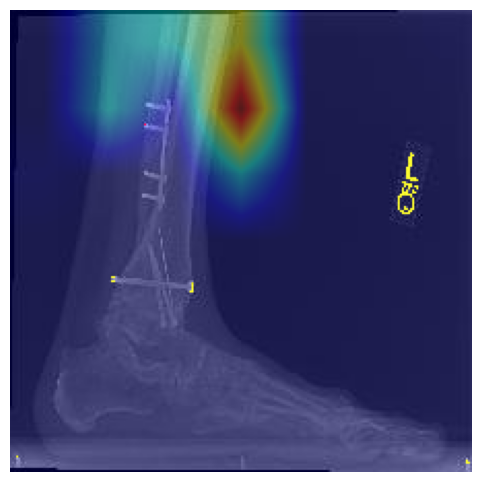

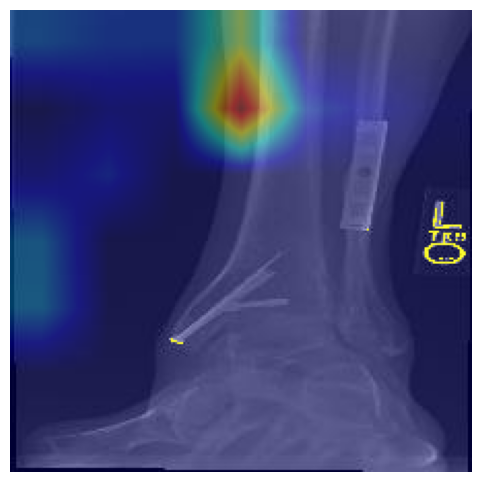

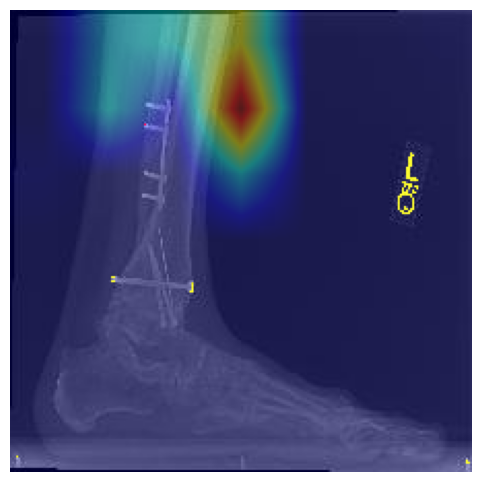

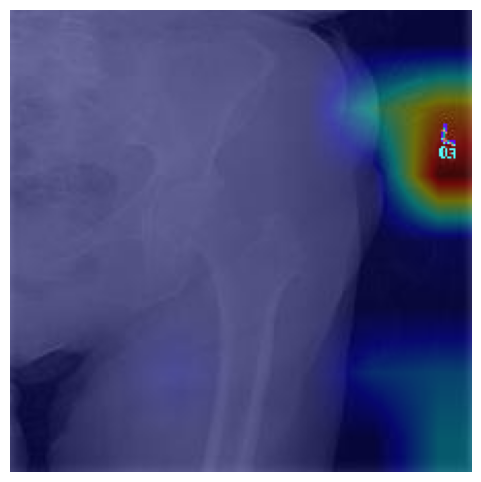

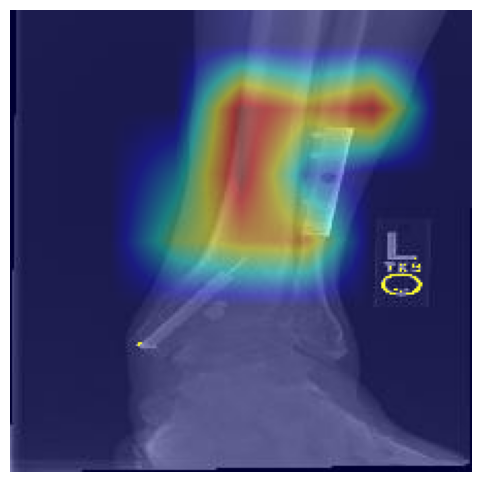

In [ ]:
# -------------------------------
# STEP 12: XAI - Grad-CAM for Fracture Localization
# -------------------------------
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf
import numpy as np

def get_img_array(img_path, size=(224, 224)):
    """Load image and convert to array"""
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=size)
    array = tf.keras.preprocessing.image.img_to_array(img)
    array = np.expand_dims(array, axis=0)
    array = array / 255.0  # normalize
    return array

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    """Generate Grad-CAM heatmap"""
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        loss = predictions[:, pred_index]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # ReLU and normalize
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

def display_gradcam_highlight(img_path, heatmap, alpha=0.6, threshold=0.3):
    """Overlay only the top heatmap regions on the image."""
    img = cv2.imread(img_path)
    img = cv2.resize(img, (224, 224))

    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap_mask = np.uint8(255 * (heatmap > threshold))
    heatmap_colored = cv2.applyColorMap(heatmap_mask, cv2.COLORMAP_JET)

    superimposed_img = cv2.addWeighted(img, 1, heatmap_colored, alpha, 0)

    plt.figure(figsize=(6,6))
    plt.axis('off')
    plt.imshow(cv2.cvtColor(superimposed_img, cv2.COLOR_BGR2RGB))
    plt.show()


# -------------------------------
# STEP 13: APPLY GRAD-CAM ON SAMPLE TEST IMAGES
# -------------------------------
# Find last convolutional layer in DenseNet121
for layer in reversed(global_model.layers):
    if 'conv' in layer.name:
        last_conv_layer_name = layer.name
        break

# Example: Visualize Grad-CAM for 5 test images
import random
test_images, test_labels = next(test_generator)
for i in range(5):
    img_array = np.expand_dims(test_images[i], axis=0)
    heatmap = make_gradcam_heatmap(img_array, global_model, last_conv_layer_name)
    # Save temporary image from array
    tmp_img_path = "/tmp/temp_img.jpg"
    plt.imsave(tmp_img_path, test_images[i])
    display_gradcam(tmp_img_path, heatmap)


Guidede Backprop

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import backend as K

# -------------------------------
# Custom ReLU for Guided Backprop
# -------------------------------
@tf.custom_gradient
def guided_relu(x):
    def grad(dy):
        return dy * tf.cast(dy > 0, "float32") * tf.cast(x > 0, "float32")
    return tf.nn.relu(x), grad


In [ ]:
# Replace all ReLU activations in the model with guided ReLU
def replace_relu_with_guided(model):
    for layer in model.layers:
        if hasattr(layer, 'activation') and layer.activation == tf.keras.activations.relu:
            layer.activation = guided_relu
    return model

# Make a guided backprop model
gb_model = tf.keras.models.clone_model(global_model)
gb_model.set_weights(global_model.get_weights())
gb_model = replace_relu_with_guided(gb_model)


In [ ]:
def guided_backprop(image, model):
    """
    image: numpy array (H, W, 3) normalized [0,1]
    model: model with guided_relu activations
    """
    img_tensor = tf.convert_to_tensor(np.expand_dims(image, axis=0), dtype=tf.float32)

    with tf.GradientTape() as tape:
        tape.watch(img_tensor)
        preds = model(img_tensor)
        top_class = preds[:, 0]  # assuming binary classification
    grads = tape.gradient(top_class, img_tensor)[0].numpy()
    return grads

# -------------------------------
# Visualization Helper
# -------------------------------
def visualize_guided_backprop(img, grads):
    fig, ax = plt.subplots(1, 2, figsize=(12,6))
    ax[0].imshow(img)
    ax[0].set_title("Original Image")
    ax[0].axis('off')

    # Normalize gradient for visualization
    grads_norm = (grads - grads.min()) / (grads.max() - grads.min())
    ax[1].imshow(grads_norm)
    ax[1].set_title("Guided Backpropagation")
    ax[1].axis('off')
    plt.show()


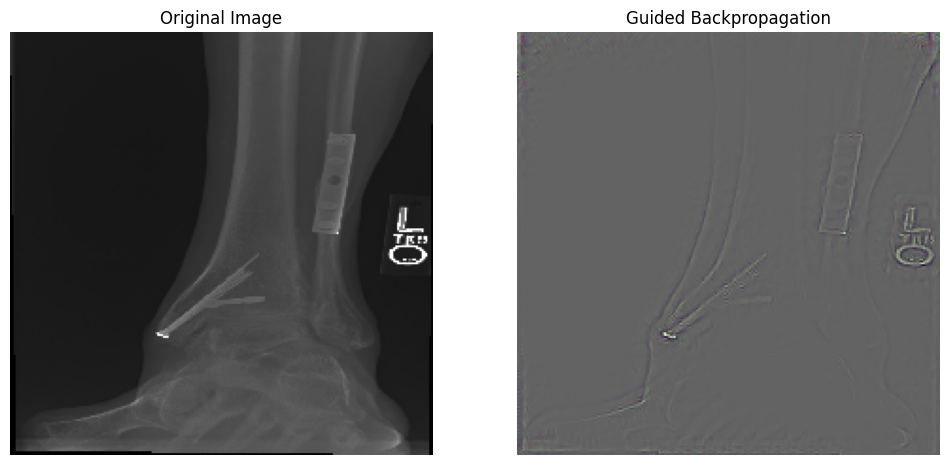

In [ ]:
# Pick a sample test image
img_path = "/kaggle/input/fracture-multi-region-x-ray-data/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/test/fractured/0012.png"
from tensorflow.keras.preprocessing import image

img = image.load_img(img_path, target_size=(IMG_HEIGHT, IMG_WIDTH))
img_array = image.img_to_array(img) / 255.0

grads = guided_backprop(img_array, gb_model)
visualize_guided_backprop(img_array, grads)



**Left Image: Original X-ray**


This is a medical X-ray of an ankle.

You can see:

The bones of the lower leg and ankle (tibia, fibula, talus).

A metallic fixation device (plate and screws), likely used to stabilize a fracture.

A visible fracture line in the distal part of the fibula, indicated by a discontinuity in the bone.

**Right Image: Guided Backpropagation Output**

Guided Backpropagation highlights the pixels that most strongly influenced the model’s prediction.

**Interpretation:**

The bright regions correspond to areas that the neural network found important for classifying this image as a fracture.

Here, the model is focusing on the fracture line and the surrounding area near the metal screws, which is correct.

Darker regions indicate less influence on the prediction.

**GRAD - CAM++**

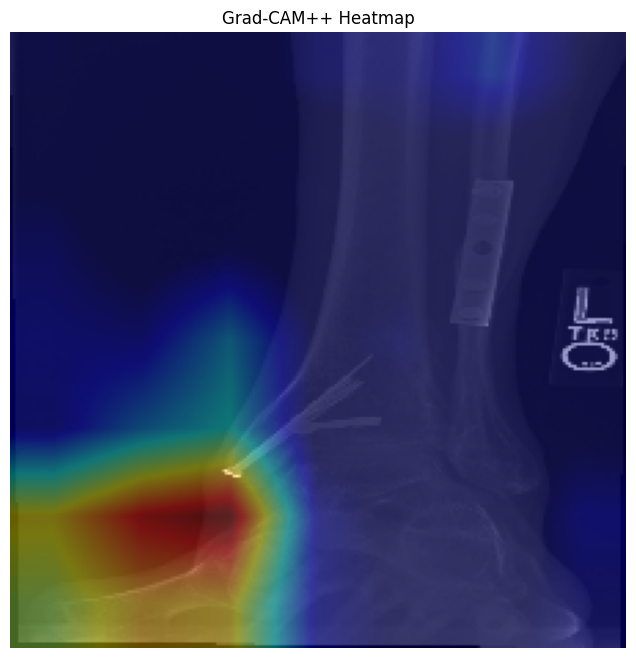

In [ ]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

# -------------------------------
# STEP 1: HELPER FUNCTIONS
# -------------------------------

def preprocess_input_image(img_path, target_size=(224, 224)):
    """Load image and preprocess for DenseNet121"""
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=target_size)
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = img_array / 255.0
    return img_array

def deprocess_cam(cam):
    """Normalize CAM for visualization"""
    cam = np.maximum(cam, 0)
    cam = cam / cam.max()
    return cam

# -------------------------------
# STEP 2: Grad-CAM++
# -------------------------------

def grad_cam_plus_plus(model, img_array, layer_name):
    """Compute Grad-CAM++ for a single image"""
    grad_model = tf.keras.models.Model(
        [model.inputs], [model.get_layer(layer_name).output, model.output]
    )

    with tf.GradientTape(persistent=True) as tape1:
        with tf.GradientTape(persistent=True) as tape2:
            conv_outputs, predictions = grad_model(img_array)
            pred_index = tf.argmax(predictions[0])
            class_output = predictions[:, pred_index]
        grads = tape2.gradient(class_output, conv_outputs)
    first_derivative = grads
    second_derivative = tape1.gradient(first_derivative, conv_outputs)

    global_sum = np.sum(conv_outputs.numpy(), axis=(1,2))
    alpha_num = second_derivative.numpy()
    alpha_denom = 2 * second_derivative.numpy() + global_sum
    alpha_denom = np.where(alpha_denom != 0.0, alpha_denom, 1e-10)
    alphas = alpha_num / alpha_denom

    weights = np.maximum(first_derivative.numpy(), 0) * alphas
    cam = np.sum(weights * conv_outputs.numpy(), axis=-1)[0]
    cam = cv2.resize(cam, (img_array.shape[2], img_array.shape[1]))
    cam = deprocess_cam(cam)
    return cam

# -------------------------------
# STEP 3: Overlay Heatmap
# -------------------------------

def overlay_heatmap(img_path, cam, alpha=0.4, colormap=cv2.COLORMAP_JET):
    img = cv2.imread(img_path)
    img = cv2.resize(img, (cam.shape[1], cam.shape[0]))
    heatmap = cv2.applyColorMap(np.uint8(255*cam), colormap)
    output = cv2.addWeighted(img, 1-alpha, heatmap, alpha, 0)
    return output

# -------------------------------
# STEP 4: APPLY Grad-CAM++ TO SAMPLE IMAGE
# -------------------------------

sample_img_path = "/kaggle/input/fracture-multi-region-x-ray-data/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/test/fractured/0012.png"


# Choose last convolutional layer
last_conv_layer = "conv5_block16_2_conv"  # DenseNet121 last conv layer

img_array = preprocess_input_image(sample_img_path)
cam = grad_cam_plus_plus(global_model, img_array, last_conv_layer)
overlay_img = overlay_heatmap(sample_img_path, cam)

plt.figure(figsize=(8,8))
plt.imshow(cv2.cvtColor(overlay_img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Grad-CAM++ Heatmap")
plt.show()


In [ ]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model

# -------------------------------
# STEP 1: IMAGE PREPROCESSING
# -------------------------------
def preprocess_input_image(img_path, target_size=(224, 224)):
    """Load image and preprocess for DenseNet121"""
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=target_size)
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = img_array / 255.0
    return img_array

def deprocess_cam(cam):
    """Normalize CAM for visualization"""
    cam = np.maximum(cam, 0)
    cam = cam / cam.max() if cam.max() != 0 else cam
    return cam

def overlay_heatmap(img_path, cam, alpha=0.4, colormap=cv2.COLORMAP_JET):
    """Overlay CAM heatmap on the original image"""
    img = cv2.imread(img_path)
    img = cv2.resize(img, (cam.shape[1], cam.shape[0]))
    heatmap = cv2.applyColorMap(np.uint8(255*cam), colormap)
    output = cv2.addWeighted(img, 1-alpha, heatmap, alpha, 0)
    return output

# -------------------------------
# STEP 2: Grad-CAM++
# -------------------------------
def grad_cam_plus_plus(model, img_array, layer_name):
    """Compute Grad-CAM++ heatmap"""
    grad_model = Model([model.inputs], [model.get_layer(layer_name).output, model.output])

    with tf.GradientTape(persistent=True) as tape1:
        with tf.GradientTape(persistent=True) as tape2:
            conv_outputs, predictions = grad_model(img_array)
            pred_index = tf.argmax(predictions[0])
            class_output = predictions[:, pred_index]
        grads = tape2.gradient(class_output, conv_outputs)
    second_grads = tape1.gradient(grads, conv_outputs)

    global_sum = np.sum(conv_outputs.numpy(), axis=(1,2))
    alpha_num = second_grads.numpy()
    alpha_denom = 2 * second_grads.numpy() + global_sum
    alpha_denom = np.where(alpha_denom != 0.0, alpha_denom, 1e-10)
    alphas = alpha_num / alpha_denom

    weights = np.maximum(grads.numpy(), 0) * alphas
    cam = np.sum(weights * conv_outputs.numpy(), axis=-1)[0]
    cam = cv2.resize(cam, (img_array.shape[2], img_array.shape[1]))
    cam = deprocess_cam(cam)
    return cam

# -------------------------------
# STEP 3: Score-CAM
# -------------------------------
def score_cam(model, img_array, layer_name):
    """Score-CAM implemented fully in TF to avoid broadcasting issues"""
    grad_model = Model([model.inputs], [model.get_layer(layer_name).output, model.output])
    conv_outputs, _ = grad_model(img_array)  # shape: (1, H, W, C)
    conv_outputs = tf.squeeze(conv_outputs)  # shape: (H, W, C)
    H, W, C = conv_outputs.shape
    cam = tf.zeros((H, W), dtype=tf.float32)

    for i in range(C):
        mask = conv_outputs[:, :, i]
        mask_resized = tf.image.resize(mask[..., tf.newaxis], (img_array.shape[1], img_array.shape[2]))
        mask_resized = tf.clip_by_value(mask_resized, 0, 1)
        mask_3ch = tf.repeat(mask_resized, repeats=3, axis=-1)
        masked_input = img_array * mask_3ch
        pred = model(masked_input)
        cam += pred[0,0] * tf.squeeze(mask_resized)

    cam = cam.numpy()
    cam = deprocess_cam(cam)
    return cam


# -------------------------------
# STEP 4: Integrated Gradients
# -------------------------------
def integrated_gradients(model, img_array, target_class_idx, baseline=None, steps=50):
    """Compute Integrated Gradients"""
    if baseline is None:
        baseline = np.zeros(img_array.shape).astype(np.float32)
    img_tensor = tf.convert_to_tensor(img_array, dtype=tf.float32)
    baseline_tensor = tf.convert_to_tensor(baseline, dtype=tf.float32)
    scaled_inputs = [baseline_tensor + (float(i)/steps)*(img_tensor - baseline_tensor) for i in range(0, steps+1)]
    grads = []
    for inp in scaled_inputs:
        with tf.GradientTape() as tape:
            tape.watch(inp)
            pred = model(inp)
            class_out = pred[:, target_class_idx]
        grad = tape.gradient(class_out, inp).numpy()
        grads.append(grad)
    avg_grads = np.mean(np.array(grads[:-1]), axis=0)
    integrated_grads = (img_array - baseline) * avg_grads
    ig = np.sum(np.abs(integrated_grads), axis=-1)[0]
    ig = deprocess_cam(ig)
    return ig

# -------------------------------
# STEP 5: APPLY XAI METHODS
# -------------------------------
sample_img_path = "/kaggle/input/fracture-multi-region-x-ray-data/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/test/fractured/0012.png"
img_array = preprocess_input_image(sample_img_path)

# Last convolutional layer for DenseNet121
last_conv_layer = "conv5_block16_2_conv"

# Grad-CAM++
cam_plus = grad_cam_plus_plus(global_model, img_array, last_conv_layer)
overlay_plus = overlay_heatmap(sample_img_path, cam_plus)

# Score-CAM
scorecam = score_cam(global_model, img_array, last_conv_layer)
overlay_score = overlay_heatmap(sample_img_path, scorecam)

# Integrated Gradients
pred_idx = int(global_model.predict(img_array)[0] > 0.5)  # binary classification
ig = integrated_gradients(global_model, img_array, pred_idx)

# -------------------------------
# STEP 6: DISPLAY RESULTS
# -------------------------------
plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.imshow(cv2.cvtColor(overlay_plus, cv2.COLOR_BGR2RGB))
plt.title("Grad-CAM++")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(cv2.cvtColor(overlay_score, cv2.COLOR_BGR2RGB))
plt.title("Score-CAM")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(ig, cmap='jet')
plt.title("Integrated Gradients")
plt.axis("off")

plt.show()


InvalidArgumentError: {{function_node __wrapped__AddV2_device_/job:localhost/replica:0/task:0/device:GPU:0}} required broadcastable shapes [Op:AddV2] name: 

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
# ====================================================
# ✅ FEDERATED LEARNING (Independent + Optimized DenseNet121)
# ====================================================

# -------------------------------
# STEP 0: IMPORT LIBRARIES
# -------------------------------
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, BatchNormalization, Dropout, Add, LayerNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.activations import swish
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

# -------------------------------
# STEP 1: PARAMETERS
# -------------------------------
IMG_HEIGHT, IMG_WIDTH = 224, 224
BATCH_SIZE = 16
EPOCHS_CLIENT = 2
FED_ROUNDS = 3
NUM_CLIENTS = 3
LR = 1e-4

data_dir = "/kaggle/input/fracture-multi-region-x-ray-data/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification"
MODEL_DIR = "/content/drive/MyDrive/federated_model"
os.makedirs(MODEL_DIR, exist_ok=True)

global_model_path = os.path.join(MODEL_DIR, "global_model_latest.h5")

# -------------------------------
# STEP 2: DATA PREPROCESSING
# -------------------------------
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)
val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    os.path.join(data_dir, "train"),
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=True
)
val_generator = val_test_datagen.flow_from_directory(
    os.path.join(data_dir, "val"),
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)
test_generator = val_test_datagen.flow_from_directory(
    os.path.join(data_dir, "test"),
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

# -------------------------------
# STEP 3: IMPROVED MODEL (DenseNet121 + Custom Layers)
# -------------------------------
def build_model():
    base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(IMG_HEIGHT, IMG_WIDTH, 3))
    for layer in base_model.layers:
        layer.trainable = False

    x = GlobalAveragePooling2D()(base_model.output)
    x1 = Dense(512, activation='swish')(x)
    x1 = BatchNormalization()(x1)
    x1 = Dropout(0.5)(x1)

    x2 = Dense(256, activation='relu')(x1)
    x2 = BatchNormalization()(x2)
    x2 = Dropout(0.4)(x2)

    x3 = Dense(128, activation='swish')(x2)
    x3 = BatchNormalization()(x3)
    x3 = Dropout(0.3)(x3)

    # Residual connection with projection
    shortcut = Dense(128, use_bias=False)(x2)
    x3 = Add()([x3, shortcut])

    x3 = LayerNormalization()(x3)
    output = Dense(1, activation='sigmoid')(x3)

    model = Model(inputs=base_model.input, outputs=output)
    model.compile(optimizer=Adam(learning_rate=LR),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

# -------------------------------
# STEP 4: CLIENT DATA SPLITTING (SIMULATION)
# -------------------------------
total_samples = train_generator.samples
indices = np.arange(total_samples)
np.random.shuffle(indices)

split_ratios = np.random.dirichlet(np.ones(NUM_CLIENTS), size=1)[0]
split_sizes = (split_ratios * total_samples).astype(int)
split_sizes[-1] = total_samples - np.sum(split_sizes[:-1])

client_indices = []
start = 0
for s in split_sizes:
    end = start + s
    client_indices.append(indices[start:end])
    start = end

print("\n📊 Client sample distribution:")
for i, s in enumerate(split_sizes):
    print(f"Client {i+1}: {s} samples ({100*s/total_samples:.2f}%)")

# -------------------------------
# STEP 5: CLIENT GENERATOR
# -------------------------------
def get_client_generator(generator, indices):
    while True:
        generator.reset()
        for x_batch, y_batch in generator:
            start_idx = (generator.batch_index - 1) * generator.batch_size
            mask = [i for i in range(len(y_batch)) if start_idx + i in indices]
            if mask:
                yield x_batch[mask], y_batch[mask]

# -------------------------------
# STEP 6: WEIGHTED FEDERATED AVERAGING
# -------------------------------
def weighted_fedavg(models, sample_counts):
    total = np.sum(sample_counts)
    avg_weights = []
    for weights_tuple in zip(*[m.get_weights() for m in models]):
        weighted_sum = np.zeros_like(weights_tuple[0])
        for w, n in zip(weights_tuple, sample_counts):
            weighted_sum += w * (n / total)
        avg_weights.append(weighted_sum)
    return avg_weights

# -------------------------------
# STEP 7: INITIALIZE GLOBAL MODEL
# -------------------------------
print("\n🚀 Initializing independent global model (no baseline)...")
global_model = build_model()

# -------------------------------
# STEP 8: FEDERATED TRAINING LOOP
# -------------------------------
for rnd in range(FED_ROUNDS):
    print(f"\n🌍 Federated Round {rnd + 1}/{FED_ROUNDS}")
    local_models = []
    sample_counts = []

    for i, client_idx in enumerate(client_indices):
        print(f"\n🏥 Training Client {i + 1} ({len(client_idx)} samples)")
        client_gen = get_client_generator(train_generator, client_idx)
        steps = int(np.ceil(len(client_idx) / BATCH_SIZE))

        local_model = build_model()
        local_model.set_weights(global_model.get_weights())
        local_model.fit(client_gen, epochs=EPOCHS_CLIENT, steps_per_epoch=steps, verbose=1)

        local_models.append(local_model)
        sample_counts.append(len(client_idx))

    new_weights = weighted_fedavg(local_models, sample_counts)
    global_model.set_weights(new_weights)
    global_model.save(global_model_path)
    print(f"✅ Saved global model after round {rnd + 1}")

# -------------------------------
# STEP 9: FINAL EVALUATION
# -------------------------------
loss, acc = global_model.evaluate(test_generator)
print(f"\n🏁 Final Global Accuracy after Federated Learning: {acc*100:.2f}%")

# -------------------------------
# STEP 10: GLOBAL FINE-TUNING
# -------------------------------
print("\n🎯 Fine-Tuning the Global Model for Higher Accuracy...")

for layer in global_model.layers[-60:]:
    layer.trainable = True

global_model.compile(optimizer=Adam(learning_rate=1e-5),
                     loss='binary_crossentropy',
                     metrics=['accuracy'])

fine_tune_epochs = 3
checkpoint = ModelCheckpoint(os.path.join(MODEL_DIR, "fine_tuned_best.h5"),
                             monitor='val_accuracy',
                             save_best_only=True,
                             verbose=1)

global_model.fit(val_generator,
                 epochs=fine_tune_epochs,
                 verbose=1,
                 callbacks=[checkpoint])

fine_tuned_path = os.path.join(MODEL_DIR, "global_model_finetuned.h5")
global_model.save(fine_tuned_path)
print(f"✅ Fine-tuned model saved at: {fine_tuned_path}")



Found 9246 images belonging to 2 classes.
Found 829 images belonging to 2 classes.
Found 506 images belonging to 2 classes.

📊 Client sample distribution:
Client 1: 3061 samples (33.11%)
Client 2: 4674 samples (50.55%)
Client 3: 1511 samples (16.34%)

🚀 Initializing independent global model (no baseline)...
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

🌍 Federated Round 1/3

🏥 Training Client 1 (3061 samples)
Epoch 1/2
192/192 ━━━━━━━━━━━━━━━━━━━━ 241s 1s/step - accuracy: 0.5403 - loss: 0.8248
Epoch 2/2
192/192 ━━━━━━━━━━━━━━━━━━━━ 41s 215ms/step - accuracy: 0.6285 - loss: 0.6724

🏥 Training Client 2 (4674 samples)
Epoch 1/2
293/293 ━━━━━━━━━━━━━━━━━━━━ 240s 723ms/step - accuracy: 0.5916 - loss: 0.7427
Epoch 2/2
293/293 ━━━━━━━━━━━━━━━━━━━━ 78s 266ms/step - accuracy: 0.7277 - loss: 0.5437

🏥 Training Client 3 (1511 samples)
Epoch 1/2
95/95 ━━━━━━━━━━━━━━━━━━━━ 120s 972ms/step - accuracy: 0.5742 - loss: 0.7931
Epoch 2/2
95/95 ━━━━━━━━━━━━━━━━━━━━ 35s 365ms/step - accuracy: 0.5166 

✅ Saved global model after round 1

🌍 Federated Round 2/3

🏥 Training Client 1 (3061 samples)
Epoch 1/2
192/192 ━━━━━━━━━━━━━━━━━━━━ 210s 945ms/step - accuracy: 0.7193 - loss: 0.5862
Epoch 2/2
192/192 ━━━━━━━━━━━━━━━━━━━━ 35s 181ms/step - accuracy: 0.6950 - loss: 0.5737

🏥 Training Client 2 (4674 samples)
Epoch 1/2
293/293 ━━━━━━━━━━━━━━━━━━━━ 238s 712ms/step - accuracy: 0.7374 - loss: 0.5396
Epoch 2/2
293/293 ━━━━━━━━━━━━━━━━━━━━ 79s 269ms/step - accuracy: 0.7768 - loss: 0.4817

🏥 Training Client 3 (1511 samples)
Epoch 1/2
95/95 ━━━━━━━━━━━━━━━━━━━━ 121s 973ms/step - accuracy: 0.6855 - loss: 0.6145
Epoch 2/2
95/95 ━━━━━━━━━━━━━━━━━━━━ 35s 371ms/step - accuracy: 0.6418 - loss: 0.6348


✅ Saved global model after round 2

🌍 Federated Round 3/3

🏥 Training Client 1 (3061 samples)
Epoch 1/2
192/192 ━━━━━━━━━━━━━━━━━━━━ 216s 969ms/step - accuracy: 0.7560 - loss: 0.5146
Epoch 2/2
192/192 ━━━━━━━━━━━━━━━━━━━━ 40s 210ms/step - accuracy: 0.7707 - loss: 0.4808

🏥 Training Client 2 (4674 samples)
Epoch 1/2
293/293 ━━━━━━━━━━━━━━━━━━━━ 237s 716ms/step - accuracy: 0.7624 - loss: 0.4855
Epoch 2/2
293/293 ━━━━━━━━━━━━━━━━━━━━ 95s 326ms/step - accuracy: 0.8060 - loss: 0.4312

🏥 Training Client 3 (1511 samples)
Epoch 1/2
95/95 ━━━━━━━━━━━━━━━━━━━━ 122s 997ms/step - accuracy: 0.6792 - loss: 0.6661
Epoch 2/2
95/95 ━━━━━━━━━━━━━━━━━━━━ 37s 387ms/step - accuracy: 0.6373 - loss: 0.6050


✅ Saved global model after round 3


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


32/32 ━━━━━━━━━━━━━━━━━━━━ 42s 578ms/step - accuracy: 0.7314 - loss: 0.5780

🏁 Final Global Accuracy after Federated Learning: 82.21%

🎯 Fine-Tuning the Global Model for Higher Accuracy...
Epoch 1/3


In [ ]:
import matplotlib.pyplot as plt
import cv2


In [ ]:
def occlusion_sensitivity(model, img, label, patch_size=30, stride=15):
    """
    Computes occlusion sensitivity map for a given image.
    Args:
        model: Trained Keras model.
        img: Input image (H, W, 3), normalized [0,1].
        label: True label (0 or 1) or target class index.
        patch_size: Size of the square patch to occlude.
        stride: Step size for sliding the occlusion window.
    Returns:
        heatmap: Occlusion sensitivity heatmap.
    """
    img_height, img_width, _ = img.shape
    baseline_pred = model.predict(np.expand_dims(img, axis=0))[0][0]

    heatmap = np.zeros((img_height, img_width))

    for y in range(0, img_height - patch_size, stride):
        for x in range(0, img_width - patch_size, stride):
            occluded = np.copy(img)
            occluded[y:y+patch_size, x:x+patch_size, :] = 0.0  # mask patch

            pred = model.predict(np.expand_dims(occluded, axis=0))[0][0]
            # Higher difference from baseline means higher importance
            diff = baseline_pred - pred if label == 1 else pred - baseline_pred
            heatmap[y:y+patch_size, x:x+patch_size] = diff

    # Normalize heatmap
    heatmap = np.maximum(heatmap, 0)
    heatmap = heatmap / np.max(heatmap)
    return heatmap


In [ ]:
def visualize_occlusion(img, heatmap):
    heatmap_resized = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
    overlay = cv2.addWeighted(np.uint8(img * 255), 0.6, heatmap_colored, 0.4, 0)

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 3, 1)
    plt.imshow(img)
    plt.title("Original Image")
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(heatmap_resized, cmap='jet')
    plt.title("Occlusion Heatmap")
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(overlay)
    plt.title("Occlusion Overlay")
    plt.axis('off')

    plt.tight_layout()
    plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 16s 16s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━

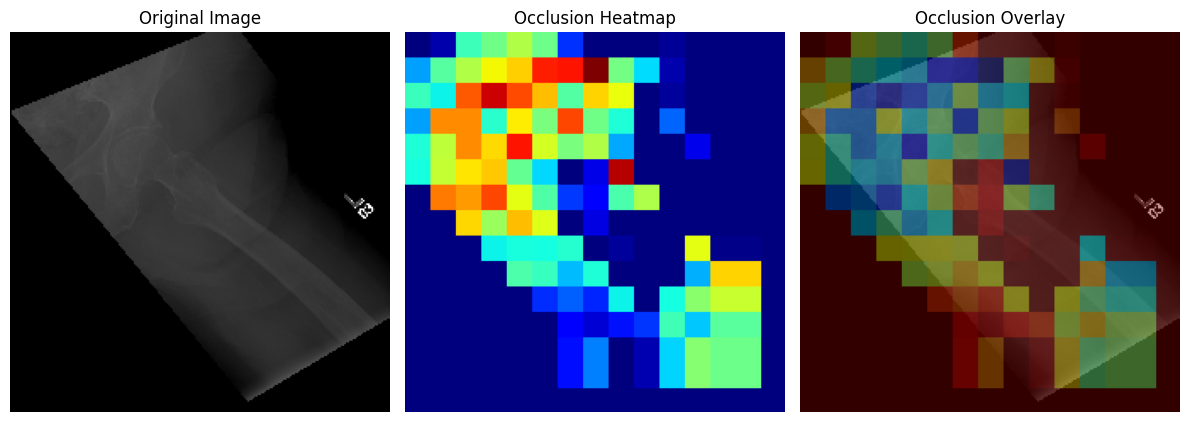

In [ ]:
from tensorflow.keras.preprocessing import image

# Pick one sample image from the test set
sample_img_path = "/kaggle/input/fracture-multi-region-x-ray-data/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/test/fractured/000151594.png"

img = image.load_img(sample_img_path, target_size=(IMG_HEIGHT, IMG_WIDTH))
img_array = image.img_to_array(img) / 255.0

# Compute heatmap
label = 1  # 1 = fracture, 0 = normal (set accordingly)
occlusion_map = occlusion_sensitivity(global_model, img_array, label, patch_size=30, stride=15)

# Visualize
visualize_occlusion(img_array, occlusion_map)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━

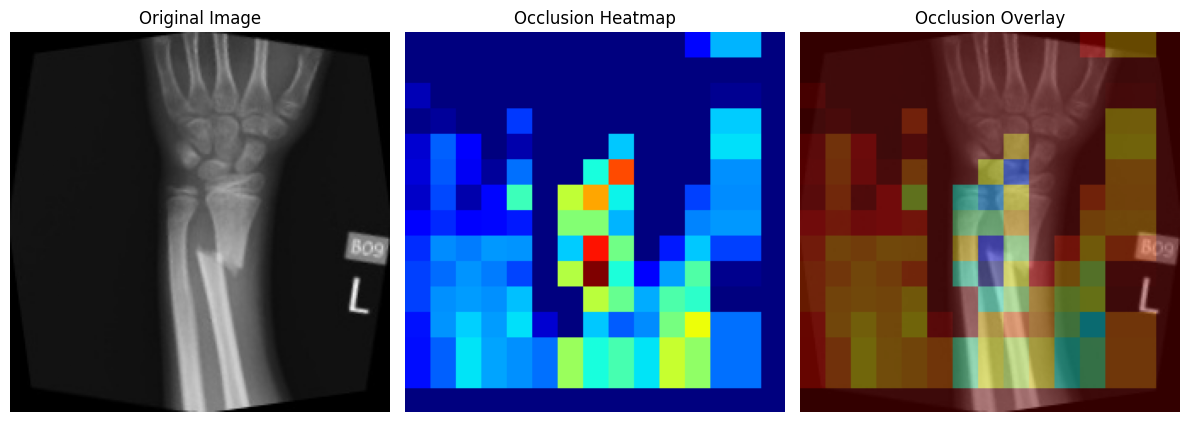

In [ ]:
from tensorflow.keras.preprocessing import image

# Pick one sample image from the test set
sample_img_path = "/kaggle/input/fracture-multi-region-x-ray-data/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/test/fractured/91-rotated3-rotated2-rotated1.jpg"

img = image.load_img(sample_img_path, target_size=(IMG_HEIGHT, IMG_WIDTH))
img_array = image.img_to_array(img) / 255.0

# Compute heatmap
label = 1  # 1 = fracture, 0 = normal (set accordingly)
occlusion_map = occlusion_sensitivity(global_model, img_array, label, patch_size=30, stride=15)

# Visualize
visualize_occlusion(img_array, occlusion_map)




✅ The red and yellow zones are the regions where the model depends most for predicting a fracture.
✅ The blue or dark zones mean occluding that part didn’t affect the model — not important for prediction.
✅ The overlay shows that the model is looking at the correct bone region, not irrelevant spots like text labels or blank background.

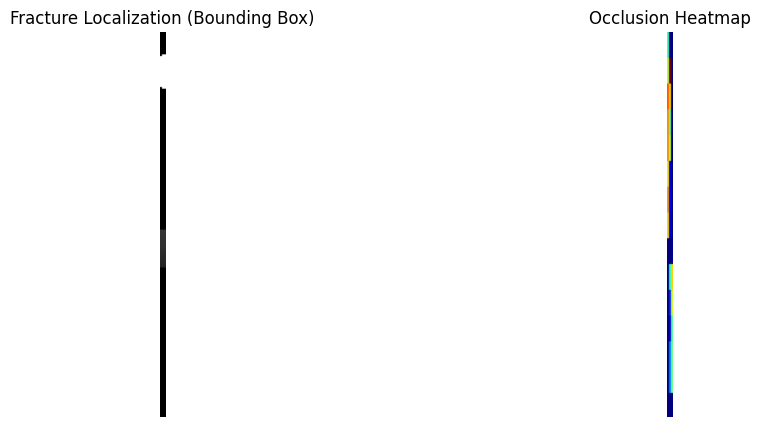

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Suppose you used these in your occlusion code
# Replace with your actual variable names if different
heatmap = occlusion_map        # 👈 your occlusion result
original_img = img_array[0]    # 👈 your test image array (normalize if needed)

# Ensure both are numpy arrays
heatmap = np.array(heatmap)
original_img = np.array(original_img)

# 1️⃣ Normalize and resize heatmap to match image size
heatmap_resized = cv2.resize(heatmap, (original_img.shape[1], original_img.shape[0]))
heatmap_norm = (heatmap_resized - np.min(heatmap_resized)) / (np.max(heatmap_resized) - np.min(heatmap_resized))

# 2️⃣ Threshold to focus on high activation (top 10%)
threshold = 0.9 * np.max(heatmap_norm)
mask = np.uint8(heatmap_norm > threshold) * 255

# 3️⃣ Find the most activated region
contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
output_img = np.uint8(original_img * 255).copy()  # convert to 8-bit image

if contours:
    # Largest contour = likely fracture region
    largest_contour = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(largest_contour)
    cv2.rectangle(output_img, (x, y), (x + w, y + h), (255, 0, 0), 3)

# 4️⃣ Display result
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.title("Fracture Localization (Bounding Box)")
plt.imshow(output_img, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Occlusion Heatmap")
plt.imshow(heatmap_norm, cmap='jet')
plt.axis('off')
plt.show()


with balanced dataset split

11/1/25


In [ ]:
# ====================================================
# ✅ FEDERATED LEARNING (Independent + Optimized DenseNet121)
# ====================================================

# -------------------------------
# STEP 0: IMPORT LIBRARIES
# -------------------------------
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, BatchNormalization, Dropout, Add, LayerNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.activations import swish
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

# -------------------------------
# STEP 1: PARAMETERS
# -------------------------------
IMG_HEIGHT, IMG_WIDTH = 224, 224
BATCH_SIZE = 16
EPOCHS_CLIENT = 2
FED_ROUNDS = 3
NUM_CLIENTS = 3
LR = 1e-4

data_dir = "/kaggle/input/fracture-multi-region-x-ray-data/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification"
MODEL_DIR = "/content/drive/MyDrive/federated_model"
os.makedirs(MODEL_DIR, exist_ok=True)

global_model_path = os.path.join(MODEL_DIR, "global_model_latest.h5")

# -------------------------------
# STEP 2: DATA PREPROCESSING
# -------------------------------
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)
val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    os.path.join(data_dir, "train"),
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=True
)
val_generator = val_test_datagen.flow_from_directory(
    os.path.join(data_dir, "val"),
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)
test_generator = val_test_datagen.flow_from_directory(
    os.path.join(data_dir, "test"),
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

# -------------------------------
# STEP 3: IMPROVED MODEL (DenseNet121 + Custom Layers)
# -------------------------------
def build_model():
    base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(IMG_HEIGHT, IMG_WIDTH, 3))
    for layer in base_model.layers:
        layer.trainable = False

    x = GlobalAveragePooling2D()(base_model.output)
    x1 = Dense(512, activation='swish')(x)
    x1 = BatchNormalization()(x1)
    x1 = Dropout(0.5)(x1)

    x2 = Dense(256, activation='relu')(x1)
    x2 = BatchNormalization()(x2)
    x2 = Dropout(0.4)(x2)

    x3 = Dense(128, activation='swish')(x2)
    x3 = BatchNormalization()(x3)
    x3 = Dropout(0.3)(x3)

    # Residual connection with projection
    shortcut = Dense(128, use_bias=False)(x2)
    x3 = Add()([x3, shortcut])

    x3 = LayerNormalization()(x3)
    output = Dense(1, activation='sigmoid')(x3)

    model = Model(inputs=base_model.input, outputs=output)
    model.compile(optimizer=Adam(learning_rate=LR),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

# -------------------------------
# STEP 4: CLIENT DATA SPLITTING (DETERMINISTIC)
# -------------------------------
total_samples = train_generator.samples
indices = np.arange(total_samples)

# Example deterministic split sizes (replace with your own if needed)
split_sizes = [3061, 4674, 1511]

# Ensure total matches dataset size
if sum(split_sizes) != total_samples:
    split_sizes[-1] = total_samples - sum(split_sizes[:-1])

client_indices = []
start = 0
for s in split_sizes:
    end = start + s
    client_indices.append(indices[start:end])
    start = end

print("\n📊 Client sample distribution (Deterministic):")
for i, s in enumerate(split_sizes):
    print(f"Client {i+1}: {s} samples ({100*s/total_samples:.2f}%)")

# -------------------------------
# STEP 5: CLIENT GENERATOR
# -------------------------------
def get_client_generator(generator, indices):
    while True:
        generator.reset()
        for x_batch, y_batch in generator:
            start_idx = (generator.batch_index - 1) * generator.batch_size
            mask = [i for i in range(len(y_batch)) if start_idx + i in indices]
            if mask:
                yield x_batch[mask], y_batch[mask]

# -------------------------------
# STEP 6: WEIGHTED FEDERATED AVERAGING
# -------------------------------
def weighted_fedavg(models, sample_counts):
    total = np.sum(sample_counts)
    avg_weights = []
    for weights_tuple in zip(*[m.get_weights() for m in models]):
        weighted_sum = np.zeros_like(weights_tuple[0])
        for w, n in zip(weights_tuple, sample_counts):
            weighted_sum += w * (n / total)
        avg_weights.append(weighted_sum)
    return avg_weights

# -------------------------------
# STEP 7: INITIALIZE GLOBAL MODEL
# -------------------------------
print("\n🚀 Initializing independent global model (no baseline)...")
global_model = build_model()

# -------------------------------
# STEP 8: FEDERATED TRAINING LOOP
# -------------------------------
for rnd in range(FED_ROUNDS):
    print(f"\n🌍 Federated Round {rnd + 1}/{FED_ROUNDS}")
    local_models = []
    sample_counts = []

    for i, client_idx in enumerate(client_indices):
        print(f"\n🏥 Training Client {i + 1} ({len(client_idx)} samples)")
        client_gen = get_client_generator(train_generator, client_idx)
        steps = int(np.ceil(len(client_idx) / BATCH_SIZE))

        local_model = build_model()
        local_model.set_weights(global_model.get_weights())
        local_model.fit(client_gen, epochs=EPOCHS_CLIENT, steps_per_epoch=steps, verbose=1)

        local_models.append(local_model)
        sample_counts.append(len(client_idx))

    new_weights = weighted_fedavg(local_models, sample_counts)
    global_model.set_weights(new_weights)
    global_model.save(global_model_path)
    print(f"✅ Saved global model after round {rnd + 1}")

# -------------------------------
# STEP 9: FINAL EVALUATION
# -------------------------------
loss, acc = global_model.evaluate(test_generator)
print(f"\n🏁 Final Global Accuracy after Federated Learning: {acc*100:.2f}%")

# -------------------------------
# STEP 10: GLOBAL FINE-TUNING
# -------------------------------
print("\n🎯 Fine-Tuning the Global Model for Higher Accuracy...")

for layer in global_model.layers[-60:]:
    layer.trainable = True

global_model.compile(optimizer=Adam(learning_rate=1e-5),
                     loss='binary_crossentropy',
                     metrics=['accuracy'])

fine_tune_epochs = 3
checkpoint = ModelCheckpoint(os.path.join(MODEL_DIR, "fine_tuned_best.h5"),
                             monitor='val_accuracy',
                             save_best_only=True,
                             verbose=1)

global_model.fit(val_generator,
                 epochs=fine_tune_epochs,
                 verbose=1,
                 callbacks=[checkpoint])

fine_tuned_path = os.path.join(MODEL_DIR, "global_model_finetuned.h5")
global_model.save(fine_tuned_path)
print(f"✅ Fine-tuned model saved at: {fine_tuned_path}")


Found 9246 images belonging to 2 classes.
Found 829 images belonging to 2 classes.
Found 506 images belonging to 2 classes.

📊 Client sample distribution (Deterministic):
Client 1: 3061 samples (33.11%)
Client 2: 4674 samples (50.55%)
Client 3: 1511 samples (16.34%)

🚀 Initializing independent global model (no baseline)...
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

🌍 Federated Round 1/3

🏥 Training Client 1 (3061 samples)
Epoch 1/2
192/192 ━━━━━━━━━━━━━━━━━━━━ 113s 425ms/step - accuracy: 0.6325 - loss: 0.6971
Epoch 2/2
192/192 ━━━━━━━━━━━━━━━━━━━━ 131s 229ms/step - accuracy: 0.7683 - loss: 0.4880

🏥 Training Client 2 (4674 samples)
Epoch 1/2
293/293 ━━━━━━━━━━━━━━━━━━━━ 132s 349ms/step - accuracy: 0.6401 - loss: 0.6885
Epoch 2/2
293/293 ━━━━━━━━━━━━━━━━━━━━ 111s 237ms/step - accuracy: 0.8028 - loss: 0.4359

🏥 Training Client 3 (1511 samples)
Epoch 1/2
95/95 ━━━━━━━━━━━━━━━━━━━━ 156s 1s/step - accuracy: 0.5692 - loss: 0.7998
Epoch 2/2
95/95 ━━━━━━━━━━━━━━━━━━━━ 111s 1s/step - a

✅ Saved global model after round 1

🌍 Federated Round 2/3

🏥 Training Client 1 (3061 samples)
Epoch 1/2
192/192 ━━━━━━━━━━━━━━━━━━━━ 93s 340ms/step - accuracy: 0.8369 - loss: 0.3765
Epoch 2/2
192/192 ━━━━━━━━━━━━━━━━━━━━ 101s 221ms/step - accuracy: 0.8512 - loss: 0.3360

🏥 Training Client 2 (4674 samples)
Epoch 1/2
293/293 ━━━━━━━━━━━━━━━━━━━━ 130s 346ms/step - accuracy: 0.8221 - loss: 0.3932
Epoch 2/2
293/293 ━━━━━━━━━━━━━━━━━━━━ 107s 226ms/step - accuracy: 0.8697 - loss: 0.3195

🏥 Training Client 3 (1511 samples)
Epoch 1/2
95/95 ━━━━━━━━━━━━━━━━━━━━ 150s 1s/step - accuracy: 0.8081 - loss: 0.4454
Epoch 2/2
95/95 ━━━━━━━━━━━━━━━━━━━━ 111s 1s/step - accuracy: 0.7963 - loss: 0.4218


✅ Saved global model after round 2

🌍 Federated Round 3/3

🏥 Training Client 1 (3061 samples)
Epoch 1/2
192/192 ━━━━━━━━━━━━━━━━━━━━ 91s 331ms/step - accuracy: 0.8734 - loss: 0.3010
Epoch 2/2
192/192 ━━━━━━━━━━━━━━━━━━━━ 102s 221ms/step - accuracy: 0.8969 - loss: 0.2455

🏥 Training Client 2 (4674 samples)
Epoch 1/2
293/293 ━━━━━━━━━━━━━━━━━━━━ 127s 337ms/step - accuracy: 0.8753 - loss: 0.2846
Epoch 2/2
293/293 ━━━━━━━━━━━━━━━━━━━━ 109s 229ms/step - accuracy: 0.8972 - loss: 0.2599

🏥 Training Client 3 (1511 samples)
Epoch 1/2
95/95 ━━━━━━━━━━━━━━━━━━━━ 157s 1s/step - accuracy: 0.8807 - loss: 0.2926
Epoch 2/2
95/95 ━━━━━━━━━━━━━━━━━━━━ 111s 1s/step - accuracy: 0.8753 - loss: 0.3034


✅ Saved global model after round 3


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


...

/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/model_checkpoint.py:302: UserWarning: Can save best model only with val_accuracy available.
  if self._should_save_model(epoch, batch, logs, filepath):


52/52 ━━━━━━━━━━━━━━━━━━━━ 74s 680ms/step - accuracy: 0.4921 - loss: 1.2636
Epoch 2/3
51/52 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.4934 - loss: 1.2148

52/52 ━━━━━━━━━━━━━━━━━━━━ 7s 142ms/step - accuracy: 0.4939 - loss: 1.2133
Epoch 3/3
51/52 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.4929 - loss: 1.0999

52/52 ━━━━━━━━━━━━━━━━━━━━ 7s 132ms/step - accuracy: 0.4925 - loss: 1.1017


✅ Fine-tuned model saved at: /content/drive/MyDrive/federated_model/global_model_finetuned.h5


In [ ]:
# -------------------------------
# STEP 11: LOAD FINAL MODEL FOR XAI
# -------------------------------
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt
import cv2

model = load_model(fine_tuned_path)
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 7,763,267 (29.61 MB)

 Trainable params: 1,696,961 (6.47 MB)

 Non-trainable params: 6,066,304 (23.14 MB)

 Optimizer params: 2 (12.00 B)

1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━

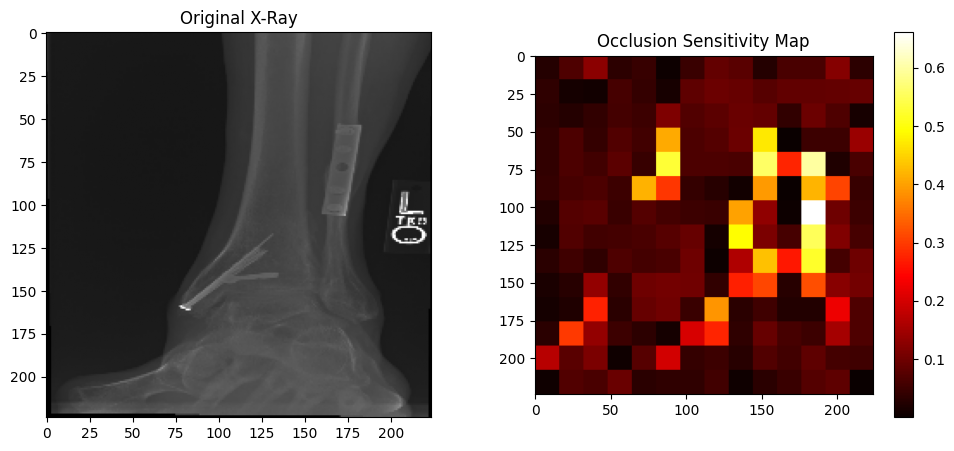

In [ ]:
# -------------------------------
# STEP 12: OCCLUSION SENSITIVITY MAP
# -------------------------------
def occlusion_sensitivity(model, img_array, label, patch_size=32, stride=16):
    """
    Slide a patch over the image and record the change in model output.
    """
    height, width, _ = img_array.shape
    output = np.zeros((height, width))
    original_pred = model.predict(img_array[np.newaxis, ...])[0][0]

    for y in range(0, height, stride):
        for x in range(0, width, stride):
            img_copy = np.copy(img_array)
            img_copy[y:y+patch_size, x:x+patch_size, :] = 0  # occlude
            new_pred = model.predict(img_copy[np.newaxis, ...])[0][0]
            output[y:y+patch_size, x:x+patch_size] = abs(original_pred - new_pred)

    return output

# Load a test image
sample_img_path = test_generator.filepaths[10]
img = cv2.imread(sample_img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_resized = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT)) / 255.0

# Compute occlusion sensitivity
occlusion_map = occlusion_sensitivity(model, img_resized, label=None)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(img_resized)
plt.title("Original X-Ray")

plt.subplot(1, 2, 2)
plt.imshow(occlusion_map, cmap='hot')
plt.title("Occlusion Sensitivity Map")
plt.colorbar()
plt.show()


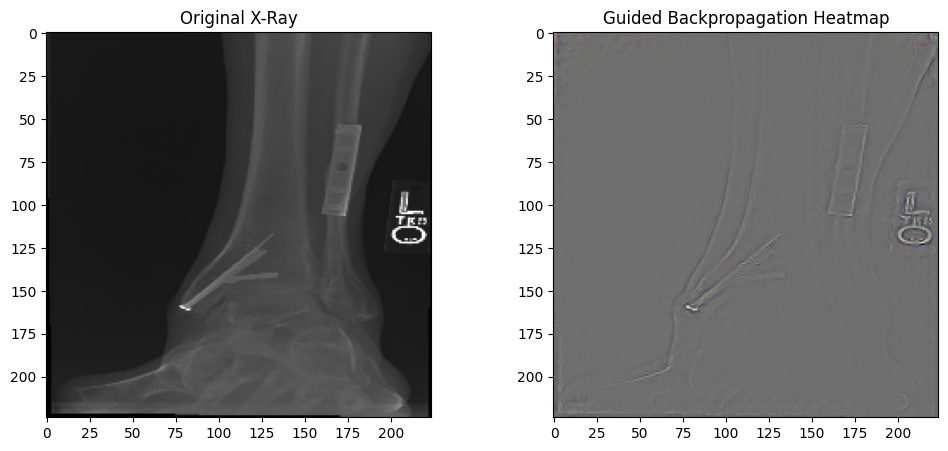

In [ ]:
# -------------------------------
# STEP 13: GUIDED BACKPROPAGATION
# -------------------------------
@tf.custom_gradient
def guided_relu(x):
    def grad(dy):
        return tf.cast(dy > 0, "float32") * tf.cast(x > 0, "float32") * dy
    return tf.nn.relu(x), grad

# Replace standard ReLU with guided ReLU
def modify_backprop(model):
    for layer in model.layers:
        if hasattr(layer, 'activation') and layer.activation == tf.keras.activations.relu:
            layer.activation = guided_relu
    return model

guided_model = modify_backprop(load_model(fine_tuned_path))

def guided_backprop(model, img_array):
    with tf.GradientTape() as tape:
        inputs = tf.cast(img_array[np.newaxis, ...], tf.float32)
        tape.watch(inputs)
        preds = model(inputs)
        loss = preds[:, 0]
    grads = tape.gradient(loss, inputs)[0]
    return grads.numpy()

# Compute guided backpropagation gradients
gb_grad = guided_backprop(guided_model, img_resized)

# Normalize for visualization
gb_norm = (gb_grad - gb_grad.min()) / (gb_grad.max() - gb_grad.min())

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(img_resized)
plt.title("Original X-Ray")

plt.subplot(1, 2, 2)
plt.imshow(gb_norm)
plt.title("Guided Backpropagation Heatmap")
plt.show()


Left Image	Right Image
The original X-ray of the patient’s ankle or foot.	The Occlusion Sensitivity Map, showing which regions the model considered most important for classifying “fracture.”
🔬 How Occlusion Sensitivity Works

The algorithm slides a gray patch (like 32×32 pixels) across the image.

For each patch location:

The patch hides (occludes) that region.

The model re-predicts the class probability.

It measures how much the prediction drops when that patch is hidden.

The difference (drop in prediction) indicates how important that patch was.

So, higher values = “this region mattered more.”

🎨 How to Interpret the Colors
Color	Meaning
🔴 Red/Orange/Yellow (Bright)	Areas where occlusion strongly changed the prediction → the model focused on these regions.
⚫ Dark/Black	Occluding these regions did not change prediction much → model found them less relevant.

In your image:

The bright yellow/orange patches near the metal implant and fractured bone edges show where the model focused its attention.

The darker background means the model ignored soft tissue or irrelevant regions.

🧠 What It Tells You About Model Behavior

✅ Model is focusing on the right place
– Bright zones align with fracture regions or surgical implants → model is learning the correct medical cues.

⚠️ Model bias check
– If bright areas appear away from bones (e.g., labels, corners, or background), that’s a sign of bias or data leakage.

🩺 Clinical trust
– If important regions correspond to medically meaningful areas, your model is interpretable and more trustworthy.

📊 Quantitative Interpretation (Optional)

You can also compute:

Mean importance per region — how much average prediction drop per patch.

Top-5 patches by sensitivity — check if those overlap with actual fracture zones.

Example:

important_patches = np.argwhere(occlusion_map > 0.5 * occlusion_map.max())
print("Top sensitive patch coordinates:", important_patches[:5])

🧩 Combine with Guided Backprop or Grad-CAM

To make the analysis richer:

Guided Backpropagation → shows fine-grained pixel importance.

Grad-CAM → shows high-level CNN feature attention (usually smoother and more intuitive).

Overlaying those on the X-ray confirms whether all interpretability methods agree on where the model “looks.”

In [ ]:
pip install torch torchvision matplotlib opencv-python numpy


Predicted class index: 883


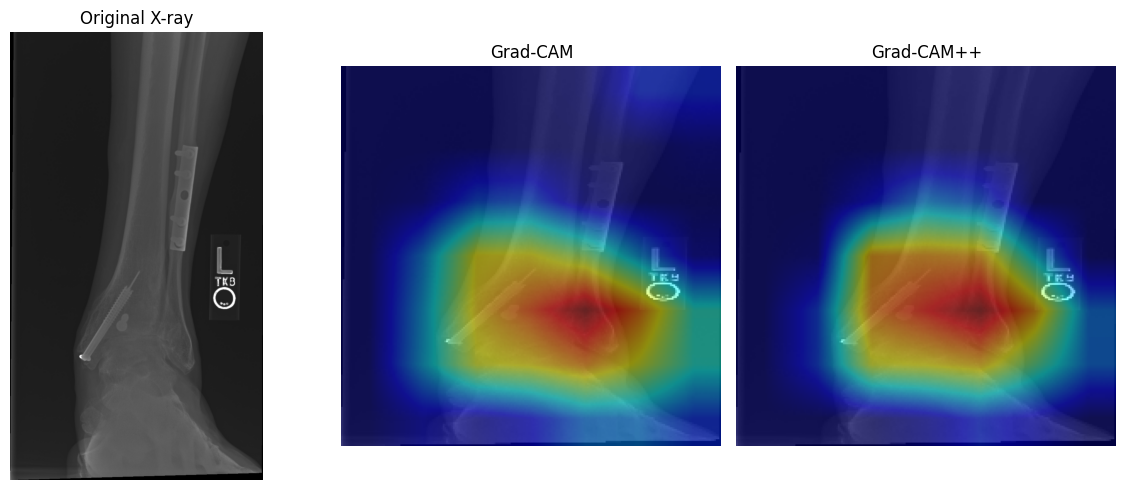

In [ ]:
import torch
import torch.nn.functional as F
from torchvision import models, transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import cv2

# -----------------------------
# 1️⃣ Load the pretrained model
# -----------------------------
model = models.resnet50(pretrained=True)
model.eval()

# -----------------------------
# 2️⃣ Load and preprocess image
# -----------------------------
img_path = "/kaggle/input/fracture-multi-region-x-ray-data/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/test/fractured/0013.png"  # <-- change to your X-ray file path
img = Image.open(img_path).convert('RGB')

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],  # ImageNet normalization
        std=[0.229, 0.224, 0.225]
    )
])
input_tensor = transform(img).unsqueeze(0)

# -----------------------------
# 3️⃣ Hook feature maps and gradients
# -----------------------------
feature_maps = []
gradients = []

def forward_hook(module, input, output):
    feature_maps.append(output)

def backward_hook(module, grad_in, grad_out):
    gradients.append(grad_out[0])

target_layer = model.layer4[-1].conv3  # Last conv layer in ResNet50
target_layer.register_forward_hook(forward_hook)
target_layer.register_full_backward_hook(backward_hook)

# -----------------------------
# 4️⃣ Forward pass and target class
# -----------------------------
output = model(input_tensor)
pred_class = output.argmax(dim=1).item()
print(f"Predicted class index: {pred_class}")

# -----------------------------
# 5️⃣ Grad-CAM computation
# -----------------------------
model.zero_grad()
class_score = output[0, pred_class]
class_score.backward(retain_graph=True)

grads_val = gradients[-1].detach().cpu().numpy()[0]
feature_val = feature_maps[-1].detach().cpu().numpy()[0]

weights = np.mean(grads_val, axis=(1, 2))  # Global average pooling
gradcam_map = np.zeros(feature_val.shape[1:], dtype=np.float32)

for i, w in enumerate(weights):
    gradcam_map += w * feature_val[i, :, :]

gradcam_map = np.maximum(gradcam_map, 0)
gradcam_map /= gradcam_map.max()

# -----------------------------
# 6️⃣ Grad-CAM++ computation
# -----------------------------
grads_val = torch.tensor(grads_val)
feature_val = torch.tensor(feature_val)

# Calculate weights for Grad-CAM++
alpha_num = grads_val.pow(2)
alpha_denom = 2 * grads_val.pow(2) + \
              (feature_val * grads_val.pow(3)).sum(dim=(1, 2), keepdim=True)
alpha_denom = torch.where(alpha_denom != 0.0, alpha_denom, torch.ones_like(alpha_denom))
alphas = alpha_num / alpha_denom

weights_plus = (alphas * F.relu(grads_val)).sum(dim=(1, 2))
gradcampp_map = (weights_plus[:, None, None] * feature_val).sum(0)
gradcampp_map = F.relu(gradcampp_map)
gradcampp_map /= gradcampp_map.max()
gradcampp_map = gradcampp_map.detach().cpu().numpy()

# -----------------------------
# 7️⃣ Visualize heatmaps
# -----------------------------
def overlay_heatmap(heatmap, img_path):
    img = cv2.imread(img_path)
    img = cv2.resize(img, (224, 224))
    heatmap = cv2.resize(heatmap, (224, 224))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    overlay = cv2.addWeighted(heatmap, 0.5, img, 0.5, 0)
    return cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)

gradcam_result = overlay_heatmap(gradcam_map, img_path)
gradcampp_result = overlay_heatmap(gradcampp_map, img_path)

plt.figure(figsize=(12, 5))
plt.subplot(1, 3, 1)
plt.imshow(img)
plt.title("Original X-ray")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(gradcam_result)
plt.title("Grad-CAM")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(gradcampp_result)
plt.title("Grad-CAM++")
plt.axis("off")

plt.tight_layout()
plt.show()


Classes: ['fractured', 'not fractured']
Epoch [1/2], Loss: 1.4056
Epoch [2/2], Loss: 0.2792

✅ Test Accuracy: 88.34%


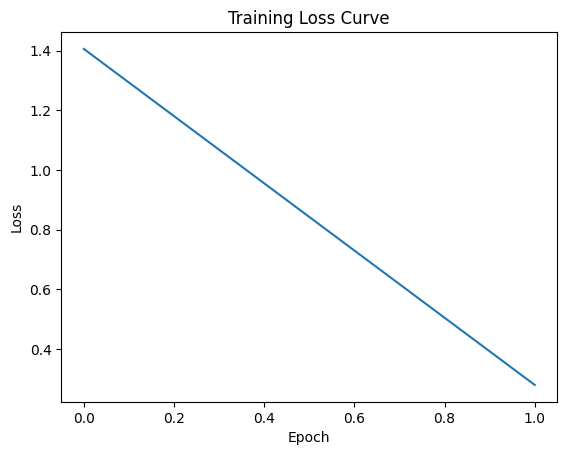

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# -------------------------------
# 1️⃣ Transformations and Data Loading
# -------------------------------
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(root='/kaggle/input/fracture-multi-region-x-ray-data/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/train', transform=transform)
test_dataset = datasets.ImageFolder(root='/kaggle/input/fracture-multi-region-x-ray-data/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/test', transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Classes: {train_dataset.classes}")

# -------------------------------
# 2️⃣ Define Baseline CNN
# -------------------------------
class BaselineCNN(nn.Module):
    def __init__(self, num_classes=2):
        super(BaselineCNN, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )

        self.fc_layers = nn.Sequential(
            nn.Linear(128 * 28 * 28, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)
        x = self.fc_layers(x)
        return x

# -------------------------------
# 3️⃣ Initialize Model, Loss, Optimizer
# -------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = BaselineCNN(num_classes=2).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# -------------------------------
# 4️⃣ Training Loop
# -------------------------------
num_epochs = 2
train_losses = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss)
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}")

# -------------------------------
# 5️⃣ Evaluation
# -------------------------------
model.eval()
correct, total = 0, 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"\n✅ Test Accuracy: {accuracy:.2f}%")

# -------------------------------
# 6️⃣ Save Model for XAI
# -------------------------------
torch.save(model.state_dict(), "baseline_cnn_xray.pth")

# Optional: Plot training loss
plt.plot(train_losses)
plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()


In [ ]:
# ====================================================
# ✅ BASELINE + FEDERATED LEARNING (Independent)
# ====================================================

# -------------------------------
# STEP 0: IMPORT LIBRARIES
# -------------------------------
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

# -------------------------------
# STEP 1: PARAMETERS
# -------------------------------
IMG_HEIGHT, IMG_WIDTH = 224, 224
BATCH_SIZE = 16
EPOCHS_BASELINE = 2
EPOCHS_CLIENT = 2
NUM_CLIENTS = 3
FED_ROUNDS = 3
LR = 1e-4

data_dir = "/kaggle/input/fracture-multi-region-x-ray-data/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification"
MODEL_DIR = "/content/drive/MyDrive/federated_model"
os.makedirs(MODEL_DIR, exist_ok=True)

# -------------------------------
# STEP 2: DATA PREPROCESSING
# -------------------------------
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)
val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    os.path.join(data_dir, "train"),
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=True
)
val_generator = val_test_datagen.flow_from_directory(
    os.path.join(data_dir, "val"),
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)
test_generator = val_test_datagen.flow_from_directory(
    os.path.join(data_dir, "test"),
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

# -------------------------------
# STEP 3: MODEL
# -------------------------------
def build_model():
    base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(IMG_HEIGHT, IMG_WIDTH, 3))
    x = GlobalAveragePooling2D()(base_model.output)
    x = Dense(128, activation='relu')(x)
    predictions = Dense(1, activation='sigmoid')(x)
    model = Model(inputs=base_model.input, outputs=predictions)

    for layer in base_model.layers:
        layer.trainable = False

    model.compile(optimizer=Adam(learning_rate=LR), loss='binary_crossentropy', metrics=['accuracy'])
    return model

# ====================================================
# ✅ BASELINE TRAINING (Independent)
# ====================================================
baseline_path = os.path.join(MODEL_DIR, "baseline_model.h5")

print("\n🚀 Training Independent Baseline DenseNet121...")
baseline_model = build_model()
checkpoint = ModelCheckpoint(baseline_path, monitor='val_accuracy', save_best_only=True)
baseline_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS_BASELINE,
    callbacks=[checkpoint],
    verbose=1
)
loss, acc = baseline_model.evaluate(val_generator)
print(f"\n✅ Baseline Accuracy (Independent): {acc*100:.2f}%")
print("Baseline model saved at:", baseline_path)

# ====================================================
# ✅ FEDERATED LEARNING (Independent from baseline)
# ====================================================

# Deterministic (fixed) client split sizes
split_sizes = [3061, 4674, 1511]

total_samples = train_generator.samples
indices = np.arange(total_samples)
np.random.seed(42)
np.random.shuffle(indices)

# Adjust last split to cover all samples exactly
split_sizes[-1] = total_samples - sum(split_sizes[:-1])

client_indices = []
start = 0
for s in split_sizes:
    end = start + s
    client_indices.append(indices[start:end])
    start = end

print("\n📊 Fixed Client sample distribution:")
for i, s in enumerate(split_sizes):
    print(f"Client {i+1}: {s} samples ({100*s/total_samples:.2f}%)")

def get_client_generator(generator, indices):
    """Return a generator that yields only samples belonging to client indices."""
    while True:
        generator.reset()
        for x_batch, y_batch in generator:
            start_idx = (generator.batch_index - 1) * generator.batch_size
            mask = [
                i for i in range(len(y_batch))
                if start_idx + i in indices
            ]
            if mask:
                yield x_batch[mask], y_batch[mask]

def weighted_fedavg(models, sample_counts):
    total = np.sum(sample_counts)
    avg_weights = []
    for weights_tuple in zip(*[m.get_weights() for m in models]):
        weighted_sum = np.zeros_like(weights_tuple[0])
        for w, n in zip(weights_tuple, sample_counts):
            weighted_sum += w * (n / total)
        avg_weights.append(weighted_sum)
    return avg_weights

# -------------------------------
# STEP 6: TRAIN FEDERATED ROUNDS
# -------------------------------
global_model_path = os.path.join(MODEL_DIR, "global_model.h5")
global_model = build_model()  # start fresh, not using baseline weights

for rnd in range(FED_ROUNDS):
    print(f"\n🌍 Federated Round {rnd+1}/{FED_ROUNDS}")
    local_models = []
    sample_counts = []

    for i, client_idx in enumerate(client_indices):
        print(f"\n🏥 Training Client {i+1} ({len(client_idx)} samples)")
        client_gen = get_client_generator(train_generator, client_idx)
        steps = int(np.ceil(len(client_idx) / BATCH_SIZE))

        local_model = build_model()
        local_model.set_weights(global_model.get_weights())
        local_model.fit(client_gen, epochs=EPOCHS_CLIENT, steps_per_epoch=steps, verbose=1)

        local_models.append(local_model)
        sample_counts.append(len(client_idx))

    new_weights = weighted_fedavg(local_models, sample_counts)
    global_model.set_weights(new_weights)
    global_model.save(global_model_path)
    print(f"✅ Saved global model after round {rnd+1} to {global_model_path}")

# -------------------------------
# STEP 7: FINAL EVALUATION
# -------------------------------
loss, acc = global_model.evaluate(test_generator)
print(f"\n🏁 Final Global Accuracy after Federated Learning: {acc*100:.2f}%")


Found 9246 images belonging to 2 classes.
Found 829 images belonging to 2 classes.
Found 506 images belonging to 2 classes.

🚀 Training Independent Baseline DenseNet121...
Epoch 1/2
578/578 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step - accuracy: 0.7063 - loss: 0.5713

578/578 ━━━━━━━━━━━━━━━━━━━━ 185s 281ms/step - accuracy: 0.7064 - loss: 0.5712 - val_accuracy: 0.7913 - val_loss: 0.4349
Epoch 2/2
578/578 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step - accuracy: 0.8677 - loss: 0.3480

578/578 ━━━━━━━━━━━━━━━━━━━━ 133s 230ms/step - accuracy: 0.8678 - loss: 0.3479 - val_accuracy: 0.8818 - val_loss: 0.3040
52/52 ━━━━━━━━━━━━━━━━━━━━ 6s 119ms/step - accuracy: 0.9087 - loss: 0.2504

✅ Baseline Accuracy (Independent): 88.18%
Baseline model saved at: /content/drive/MyDrive/federated_model/baseline_model.h5

📊 Fixed Client sample distribution:
Client 1: 3061 samples (33.11%)
Client 2: 4674 samples (50.55%)
Client 3: 1511 samples (16.34%)

🌍 Federated Round 1/3

🏥 Training Client 1 (3061 samples)
Epoch 1/2
192/192 ━━━━━━━━━━━━━━━━━━━━ 181s 823ms/step - accuracy: 0.5193 - loss: 0.7498
Epoch 2/2
192/192 ━━━━━━━━━━━━━━━━━━━━ 39s 204ms/step - accuracy: 0.7828 - loss: 0.5358

🏥 Training Client 2 (4674 samples)
Epoch 1/2
293/293 ━━━━━━━━━━━━━━━━━━━━ 195s 589ms/step - accuracy: 0.6105 - loss: 0.6740
Epoch 2/2
293/293 ━━━━━━━━━━━━━━━━━━━━ 62s 210ms/step - accuracy: 0.8111 - loss: 0.4678

🏥 Training Client 3 (1511 samples)
Epoch 1/2
95/95 ━━━━━━━━━━━━━━━━━━━━ 109s 928ms/step - accura

✅ Saved global model after round 1 to /content/drive/MyDrive/federated_model/global_model.h5

🌍 Federated Round 2/3

🏥 Training Client 1 (3061 samples)
Epoch 1/2
192/192 ━━━━━━━━━━━━━━━━━━━━ 165s 733ms/step - accuracy: 0.8439 - loss: 0.4349
Epoch 2/2
192/192 ━━━━━━━━━━━━━━━━━━━━ 39s 204ms/step - accuracy: 0.8002 - loss: 0.4485

🏥 Training Client 2 (4674 samples)
Epoch 1/2
293/293 ━━━━━━━━━━━━━━━━━━━━ 197s 599ms/step - accuracy: 0.7938 - loss: 0.4611
Epoch 2/2
293/293 ━━━━━━━━━━━━━━━━━━━━ 64s 218ms/step - accuracy: 0.8467 - loss: 0.3924

🏥 Training Client 3 (1511 samples)
Epoch 1/2
95/95 ━━━━━━━━━━━━━━━━━━━━ 105s 858ms/step - accuracy: 0.8105 - loss: 0.4388
Epoch 2/2
95/95 ━━━━━━━━━━━━━━━━━━━━ 22s 227ms/step - accuracy: 0.7856 - loss: 0.4713


✅ Saved global model after round 2 to /content/drive/MyDrive/federated_model/global_model.h5

🌍 Federated Round 3/3

🏥 Training Client 1 (3061 samples)
Epoch 1/2
192/192 ━━━━━━━━━━━━━━━━━━━━ 167s 753ms/step - accuracy: 0.8473 - loss: 0.3625
Epoch 2/2
192/192 ━━━━━━━━━━━━━━━━━━━━ 41s 212ms/step - accuracy: 0.8684 - loss: 0.3478

🏥 Training Client 2 (4674 samples)
Epoch 1/2
293/293 ━━━━━━━━━━━━━━━━━━━━ 214s 649ms/step - accuracy: 0.8749 - loss: 0.3459
Epoch 2/2
293/293 ━━━━━━━━━━━━━━━━━━━━ 71s 243ms/step - accuracy: 0.8557 - loss: 0.3691

🏥 Training Client 3 (1511 samples)
Epoch 1/2
95/95 ━━━━━━━━━━━━━━━━━━━━ 107s 897ms/step - accuracy: 0.8439 - loss: 0.3754
Epoch 2/2
95/95 ━━━━━━━━━━━━━━━━━━━━ 24s 252ms/step - accuracy: 0.8068 - loss: 0.4083


✅ Saved global model after round 3 to /content/drive/MyDrive/federated_model/global_model.h5
32/32 ━━━━━━━━━━━━━━━━━━━━ 30s 462ms/step - accuracy: 0.8256 - loss: 0.3927

🏁 Final Global Accuracy after Federated Learning: 80.63%


federated
dense121+custom layer
with federated depending on the baseline


In [ ]:
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True


In [ ]:
# -------------------------------
# STEP 0: IMPORT LIBRARIES
# -------------------------------
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, BatchNormalization, Dropout, Add, LayerNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True


In [ ]:
from PIL import Image
import os

root_dir = "/kaggle/input/fracture-multi-region-x-ray-data/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification"

corrupted = []
for subdir, dirs, files in os.walk(root_dir):
    for file in files:
        filepath = os.path.join(subdir, file)
        try:
            img = Image.open(filepath)
            img.verify()  # verify that it's not broken
        except (IOError, SyntaxError) as e:
            corrupted.append(filepath)

print(f"🧩 Found {len(corrupted)} corrupted images")
for f in corrupted:
    print(f)


🧩 Found 0 corrupted images


In [ ]:
for f in corrupted:
    os.remove(f)


In [ ]:
def safe_load_img(path, target_size):
    try:
        img = tf.keras.utils.load_img(path, target_size=target_size)
        return tf.keras.utils.img_to_array(img)
    except Exception as e:
        print(f"⚠️ Skipping corrupted image: {path}")
        return None


In [ ]:
# ====================================================
# ✅ BASELINE + FEDERATED LEARNING (Dependent Setup)
# ====================================================

# -------------------------------
# STEP 0: IMPORT LIBRARIES
# -------------------------------
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, BatchNormalization, Dropout, Add, LayerNormalization
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

# -------------------------------
# STEP 1: PARAMETERS
# -------------------------------
IMG_HEIGHT, IMG_WIDTH = 224, 224
BATCH_SIZE = 16
EPOCHS_BASELINE = 2
EPOCHS_CLIENT = 2
FED_ROUNDS = 3
NUM_CLIENTS = 3
LR = 1e-4

data_dir = "/root/.cache/kagglehub/datasets/bmadushanirodrigo/fracture-multi-region-x-ray-data/versions/2/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification"
MODEL_DIR = "/content/drive/MyDrive/federated_model"
os.makedirs(MODEL_DIR, exist_ok=True)

baseline_path = os.path.join(MODEL_DIR, "baseline_model.h5")
global_model_path = os.path.join(MODEL_DIR, "global_model_latest.h5")

# -------------------------------
# STEP 2: DATA PREPROCESSING
# -------------------------------
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)
val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    os.path.join(data_dir, "train"),
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=True
)
val_generator = val_test_datagen.flow_from_directory(
    os.path.join(data_dir, "val"),
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)
test_generator = val_test_datagen.flow_from_directory(
    os.path.join(data_dir, "test"),
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

# -------------------------------
# STEP 3: BASELINE MODEL (Simple DenseNet121)
# -------------------------------
def build_baseline_model():
    base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(IMG_HEIGHT, IMG_WIDTH, 3))
    x = GlobalAveragePooling2D()(base_model.output)
    x = Dense(128, activation='relu')(x)
    output = Dense(1, activation='sigmoid')(x)
    model = Model(inputs=base_model.input, outputs=output)

    for layer in base_model.layers:
        layer.trainable = False

    model.compile(optimizer=Adam(learning_rate=LR), loss='binary_crossentropy', metrics=['accuracy'])
    return model

# -------------------------------
# STEP 4: TRAIN OR LOAD BASELINE
# -------------------------------
if os.path.exists(baseline_path):
    print("✅ Loading existing baseline model...")
    baseline_model = load_model(baseline_path)
else:
    print("\n🚀 Training baseline DenseNet121 model...")
    baseline_model = build_baseline_model()
    checkpoint = ModelCheckpoint(baseline_path, monitor='val_accuracy', save_best_only=True, verbose=1)
    baseline_model.fit(
        train_generator,
        validation_data=val_generator,
        epochs=EPOCHS_BASELINE,
        callbacks=[checkpoint],
        verbose=1
    )
    print(f"✅ Baseline model saved at: {baseline_path}")

loss, acc = baseline_model.evaluate(val_generator)
print(f"\n📊 Baseline Validation Accuracy: {acc*100:.2f}%")

# -------------------------------
# STEP 5: OPTIMIZED MODEL
# -------------------------------
def build_optimized_model():
    base_model = DenseNet121(weights=None, include_top=False, input_shape=(IMG_HEIGHT, IMG_WIDTH, 3))
    for layer in base_model.layers:
        layer.trainable = False

    x = GlobalAveragePooling2D()(base_model.output)
    x1 = Dense(512, activation='swish')(x)
    x1 = BatchNormalization()(x1)
    x1 = Dropout(0.5)(x1)

    x2 = Dense(256, activation='relu')(x1)
    x2 = BatchNormalization()(x2)
    x2 = Dropout(0.4)(x2)

    x3 = Dense(128, activation='swish')(x2)
    x3 = BatchNormalization()(x3)
    x3 = Dropout(0.3)(x3)

    shortcut = Dense(128, use_bias=False)(x2)
    x3 = Add()([x3, shortcut])
    x3 = LayerNormalization()(x3)

    output = Dense(1, activation='sigmoid')(x3)
    model = Model(inputs=base_model.input, outputs=output)
    model.compile(optimizer=Adam(learning_rate=LR), loss='binary_crossentropy', metrics=['accuracy'])
    return model

# -------------------------------
# STEP 6: CLIENT DATA SPLIT
# -------------------------------
total_samples = train_generator.samples
indices = np.arange(total_samples)
split_sizes = [3061, 4674, 1511]

if sum(split_sizes) != total_samples:
    split_sizes[-1] = total_samples - sum(split_sizes[:-1])

client_indices = []
start = 0
for s in split_sizes:
    end = start + s
    client_indices.append(indices[start:end])
    start = end

print("\n📊 Client sample distribution (Deterministic):")
for i, s in enumerate(split_sizes):
    print(f"Client {i+1}: {s} samples ({100*s/total_samples:.2f}%)")

# -------------------------------
# STEP 7: HELPER FUNCTIONS
# -------------------------------
def get_client_generator(generator, indices):
    while True:
        generator.reset()
        for x_batch, y_batch in generator:
            start_idx = (generator.batch_index - 1) * generator.batch_size
            mask = [i for i in range(len(y_batch)) if start_idx + i in indices]
            if mask:
                yield x_batch[mask], y_batch[mask]

def weighted_fedavg(models, sample_counts):
    total = np.sum(sample_counts)
    avg_weights = []
    for weights_tuple in zip(*[m.get_weights() for m in models]):
        weighted_sum = np.zeros_like(weights_tuple[0])
        for w, n in zip(weights_tuple, sample_counts):
            weighted_sum += w * (n / total)
        avg_weights.append(weighted_sum)
    return avg_weights

# -------------------------------
# STEP 8: INITIALIZE GLOBAL MODEL PROPERLY
# -------------------------------
print("\n🔁 Initializing global model from baseline weights...")

global_model = build_optimized_model()

# ✅ Transfer only DenseNet121 base weights
baseline_base = baseline_model.layers[1]  # DenseNet base in baseline
global_base = global_model.layers[1]      # DenseNet base in global
global_base.set_weights(baseline_base.get_weights())

print("✅ Transferred DenseNet base weights from baseline → global model")

# -------------------------------
# STEP 9: FEDERATED TRAINING
# -------------------------------
for rnd in range(FED_ROUNDS):
    print(f"\n🌍 Federated Round {rnd + 1}/{FED_ROUNDS}")
    local_models, sample_counts = [], []

    for i, client_idx in enumerate(client_indices):
        print(f"\n🏥 Training Client {i + 1} ({len(client_idx)} samples)")
        client_gen = get_client_generator(train_generator, client_idx)
        steps = int(np.ceil(len(client_idx) / BATCH_SIZE))

        local_model = build_optimized_model()
        local_base = local_model.layers[1]
        local_base.set_weights(global_base.get_weights())

        local_model.fit(client_gen, epochs=EPOCHS_CLIENT, steps_per_epoch=steps, verbose=1)

        local_models.append(local_model)
        sample_counts.append(len(client_idx))

    new_weights = weighted_fedavg(local_models, sample_counts)
    global_model.set_weights(new_weights)
    global_model.save(global_model_path)
    print(f"✅ Saved global model after round {rnd + 1}")

# -------------------------------
# STEP 10: FINAL EVALUATION
# -------------------------------
loss, acc = global_model.evaluate(test_generator)
print(f"\n🏁 Final Global Accuracy after Federated Learning: {acc*100:.2f}%")

# -------------------------------
# STEP 11: FINE-TUNING
# -------------------------------
print("\n🎯 Fine-Tuning the Global Model for Higher Accuracy...")
for layer in global_model.layers[-60:]:
    layer.trainable = True

global_model.compile(optimizer=Adam(learning_rate=1e-5),
                     loss='binary_crossentropy',
                     metrics=['accuracy'])

fine_tune_epochs = 3
checkpoint = ModelCheckpoint(os.path.join(MODEL_DIR, "fine_tuned_best.h5"),
                             monitor='val_accuracy',
                             save_best_only=True,
                             verbose=1)

global_model.fit(val_generator, epochs=fine_tune_epochs, verbose=1, callbacks=[checkpoint])
fine_tuned_path = os.path.join(MODEL_DIR, "global_model_finetuned.h5")
global_model.save(fine_tuned_path)
print(f"✅ Fine-tuned model saved at: {fine_tuned_path}")


Found 9246 images belonging to 2 classes.
Found 829 images belonging to 2 classes.
Found 506 images belonging to 2 classes.
✅ Loading existing baseline model...


52/52 ━━━━━━━━━━━━━━━━━━━━ 29s 265ms/step - accuracy: 0.8303 - loss: 0.3602

📊 Baseline Validation Accuracy: 88.90%

📊 Client sample distribution (Deterministic):
Client 1: 3061 samples (33.11%)
Client 2: 4674 samples (50.55%)
Client 3: 1511 samples (16.34%)

🔁 Initializing global model from baseline weights...
✅ Transferred DenseNet base weights from baseline → global model

🌍 Federated Round 1/3

🏥 Training Client 1 (3061 samples)
Epoch 1/2
192/192 ━━━━━━━━━━━━━━━━━━━━ 96s 350ms/step - accuracy: 0.5523 - loss: 0.8095
Epoch 2/2
192/192 ━━━━━━━━━━━━━━━━━━━━ 98s 225ms/step - accuracy: 0.5906 - loss: 0.7247

🏥 Training Client 2 (4674 samples)
Epoch 1/2
293/293 ━━━━━━━━━━━━━━━━━━━━ 131s 344ms/step - accuracy: 0.5554 - loss: 0.7973
Epoch 2/2
293/293 ━━━━━━━━━━━━━━━━━━━━ 101s 218ms/step - accuracy: 0.5963 - loss: 0.7099

🏥 Training Client 3 (1511 samples)
Epoch 1/2
95/95 ━━━━━━━━━━━━━━━━━━━━ 149s 1s/step - accuracy: 0.5447 - loss: 0.8339
Epoch 2/2
95/95 ━━━━━━━━━━━━━━━━━━━━ 106s 1s/step - a

✅ Saved global model after round 1

🌍 Federated Round 2/3

🏥 Training Client 1 (3061 samples)
Epoch 1/2
192/192 ━━━━━━━━━━━━━━━━━━━━ 89s 322ms/step - accuracy: 0.5448 - loss: 0.8178
Epoch 2/2
192/192 ━━━━━━━━━━━━━━━━━━━━ 98s 215ms/step - accuracy: 0.5944 - loss: 0.7109

🏥 Training Client 2 (4674 samples)
Epoch 1/2
293/293 ━━━━━━━━━━━━━━━━━━━━ 124s 331ms/step - accuracy: 0.5339 - loss: 0.8084
Epoch 2/2
293/293 ━━━━━━━━━━━━━━━━━━━━ 102s 216ms/step - accuracy: 0.6160 - loss: 0.6876

🏥 Training Client 3 (1511 samples)
Epoch 1/2
95/95 ━━━━━━━━━━━━━━━━━━━━ 143s 1s/step - accuracy: 0.5467 - loss: 0.8114
Epoch 2/2
95/95 ━━━━━━━━━━━━━━━━━━━━ 104s 1s/step - accuracy: 0.6022 - loss: 0.7495


✅ Saved global model after round 2

🌍 Federated Round 3/3

🏥 Training Client 1 (3061 samples)
Epoch 1/2
192/192 ━━━━━━━━━━━━━━━━━━━━ 90s 332ms/step - accuracy: 0.5454 - loss: 0.8064
Epoch 2/2
192/192 ━━━━━━━━━━━━━━━━━━━━ 96s 211ms/step - accuracy: 0.5993 - loss: 0.6932

🏥 Training Client 2 (4674 samples)
Epoch 1/2
293/293 ━━━━━━━━━━━━━━━━━━━━ 126s 336ms/step - accuracy: 0.5345 - loss: 0.8130
Epoch 2/2
293/293 ━━━━━━━━━━━━━━━━━━━━ 100s 214ms/step - accuracy: 0.5723 - loss: 0.7119

🏥 Training Client 3 (1511 samples)
Epoch 1/2
95/95 ━━━━━━━━━━━━━━━━━━━━ 148s 1s/step - accuracy: 0.5460 - loss: 0.8319
Epoch 2/2
95/95 ━━━━━━━━━━━━━━━━━━━━ 105s 1s/step - accuracy: 0.5597 - loss: 0.7729


✅ Saved global model after round 3
32/32 ━━━━━━━━━━━━━━━━━━━━ 32s 506ms/step - accuracy: 0.8024 - loss: 0.5122

🏁 Final Global Accuracy after Federated Learning: 47.04%

🎯 Fine-Tuning the Global Model for Higher Accuracy...
Epoch 1/3
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 524ms/step - accuracy: 0.4974 - loss: 0.7474

/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/model_checkpoint.py:302: UserWarning: Can save best model only with val_accuracy available.
  if self._should_save_model(epoch, batch, logs, filepath):


52/52 ━━━━━━━━━━━━━━━━━━━━ 70s 539ms/step - accuracy: 0.4977 - loss: 0.7475
Epoch 2/3
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - accuracy: 0.5114 - loss: 0.7373

52/52 ━━━━━━━━━━━━━━━━━━━━ 7s 125ms/step - accuracy: 0.5115 - loss: 0.7374
Epoch 3/3
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.4985 - loss: 0.7612

52/52 ━━━━━━━━━━━━━━━━━━━━ 8s 144ms/step - accuracy: 0.4985 - loss: 0.7610


✅ Fine-tuned model saved at: /content/drive/MyDrive/federated_model/global_model_finetuned.h5
